<h1 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> AIRBNB PRICE PREDICTION IN CAPE TOWN: ADVANCED MACHINE LEARNING ANALYSIS 
</h1>

### Executive Summary

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
This capstone project focuses on building an advanced machine learning framework to improve Airbnb price prediction in Cape Town’s tourism-driven economy. The study integrates both traditional and deep learning models to enhance pricing accuracy and uncover key market factors influencing rental value. By delivering data-driven recommendations and accurate price estimates, the project supports Airbnb hosts in making informed pricing decisions and contributes to wider research on the growing digital accommodation market in African urban settings. The hybrid modeling approach ensures reliable performance while incorporating innovative techniques to capture complex pricing patterns.
</div>

<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 1. Business Understanding </h2>

### 1.1 Problem Statement

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
Airbnb hosts in Cape Town often struggle to determine the best nightly prices that maximize revenue while maintaining strong booking demand. With varying tourism seasons, diverse accommodation types and distinct neighborhood dynamics, pricing decisions become highly complex. This project aims to provide a data-driven pricing solution designed specifically for Cape Town’s market, helping hosts make informed and competitive pricing choices.
</div>

### 1.2 Project Objectives

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**Main Objective:**  
Create a reliable and insightful machine learning solution capable of predicting competitive Airbnb prices in Cape Town, empowering hosts with clear, data-backed pricing guidance.

**Specific Objectives:**  
1. **Test and evaluate a range of machine learning models** including baseline regressors and neural networks to identify the most effective pricing approach for the Cape Town market.  
2. **Engineer meaningful, context-specific features** such as neighborhood effects, seasonal tourism trends, amenities and host metrics that influence price variations.  
3. **Implement explainability techniques** to help hosts understand which factors drive pricing outcomes, ensuring transparency in model decision-making.  
4. **Deploy an interactive web-based pricing tool** that demonstrates practical usefulness and enables hosts to obtain real-time pricing recommendations.

</div>

### 1.3 Success Metrics

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

- **Primary**: RMSE (Root Mean Squared Error) on log-transformed prices targeting <0.15
- **Secondary**: >70% of predictions within 15% of actual prices
- **Technical**: R² score >0.65 with comprehensive model explainability
- **Business**: Clear identification of top 5 pricing drivers in Cape Town market

</div>

### 1.4 Stakeholder Value

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
- **Airbnb Hosts**: Data-driven pricing decisions increasing revenue by 15-25%
- **Platform Efficiency**: Reduced price volatility and improved market transparency  
- **Tourism Industry**: Better understanding of Cape Town's accommodation market dynamics
- **Research Community**: Insights into African sharing economy and emerging market applications

</div>

<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 2. Data Understanding </h2>

### Purpose

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
The objective of this phase is to develop a thorough understanding of the dataset by exploring its structure, content and key characteristics. This involves assessing the quality and completeness of the data, identifying potential issues such as missing values or inconsistencies and uncovering initial patterns, trends and relationships among variables. Gaining these insights provides a strong foundation for effective data preprocessing, feature engineering and subsequent modeling steps.
</div>

### 2.1 Data Sources

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**Primary Data Source: Inside Airbnb - Cape Town**

**Source URL:** [http://insideairbnb.com/cape-town/](http://insideairbnb.com/cape-town/)

**Data Snapshot Date:** 28 September 2024

</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

### Dataset Strategy for Cape Town Market Analysis

### Core Dataset: `listings.csv.gz`

- **Property Characteristics**: `property_type`, `room_type`, `accommodates`, `bedrooms`, `bathrooms`
- **Location Data**: `neighbourhood_cleansed`, `latitude`, `longitude` (replaces neighbourhoods.csv)
- **Amenities Analysis**: Full amenities list including Cape Town-specific features (braai facilities, mountain views, security)
- **Host Factors**: `host_since`, `host_response_rate`, `host_is_superhost`, `host_identity_verified`
- **Review Metrics**: Comprehensive rating columns (`review_scores_rating`, `review_scores_accuracy`, `review_scores_cleanliness`, `review_scores_checkin`, `review_scores_communication`, `review_scores_location`, `review_scores_value`) - replaces detailed reviews analysis
- **Pricing & Availability**: `price`, `minimum_nights`, `availability_365`

### Supplemental Dataset: `calendar.csv.gz`
- **Seasonal Analysis**: 365-day pricing patterns for Cape Town's tourism cycles
- **Dynamic Pricing**: Enables optimization based on seasonal demand fluctuations
- **Occupancy Insights**: Availability tracking to support revenue maximization goals

## Rationale for Streamlined Approach:
This focused dataset strategy maintains the project's core analytical capabilities while ensuring efficient scope management. The key review scores from listings.csv provide sufficient reputation metrics, and geographic coordinates enable robust location analysis without neighborhood boundary files.

- **Data Volume:** ~26,000+ listings capturing Cape Town's diverse accommodation market
- **Geographic Coverage:** Full metropolitan area with latitude/longitude precision
- **Temporal Scope:** Static snapshot + 365-day dynamic pricing calendar

</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### 2.2 Initial Data Exploration

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### What to Do:
```python
# Load dataset and perform initial inspection
df.shape          # Check dimensions (rows, columns)
df.info()         # Data types and memory usage
df.head()         # First few rows for visual inspection
df.describe()     # Statistical summary for numerical features
df.isnull().sum() # Count missing values per column
```

#### Key Tasks:
- Identify data types (numeric, categorical, text, datetime)
- Check for obvious data quality issues
- Understand the structure and organization
- Note any immediate concerns or surprises

</div>

In [2]:
# Loading the datasets
listings = pd.read_csv('data/listings.csv.gz')
calendar = pd.read_csv('data/calendar.csv.gz')

print(f"Listings Shape: {listings.shape}")

print(f"Calendar Shape: {calendar.shape}")

Listings Shape: (465, 79)
Calendar Shape: (169725, 7)


In [3]:
# Listings Overview
listings.info()

display(listings.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            465 non-null    int64  
 1   listing_url                                   465 non-null    object 
 2   scrape_id                                     465 non-null    int64  
 3   last_scraped                                  465 non-null    object 
 4   source                                        465 non-null    object 
 5   name                                          465 non-null    object 
 6   description                                   455 non-null    object 
 7   neighborhood_overview                         193 non-null    object 
 8   picture_url                                   465 non-null    object 
 9   host_id                                       465 non-null    int

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250906174623,2025-09-06,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250906174623,2025-09-06,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.81,4.77,NaN,f,5,5,0,0,2.31
2,5651579,https://www.airbnb.com/rooms/5651579,20250906174623,2025-09-06,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.76,4.64,NaN,f,2,1,1,0,2.96


### 2.3 Dataset Overview

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Dataset Dimensions:
- **Total Records**: 26,877 Airbnb listings
- **Features**: 79 columns spanning multiple data categories
- **Memory Usage**: 16.2+ MB

#### Data Type Distribution
- **Numerical Features**: 44 columns (24 float64, 20 int64)
- **Categorical/Text Features**: 35 object columns
- **Missing Columns**: 1 completely empty column (`neighbourhood_group_cleansed`)

#### Critical Data Quality Observations

**Immediate Concerns Identified:**

**1. Target Variable Issues:**
```python
price: 22,476 non-null (4,401 missing ~16.4%) | Object type (should be numeric)
```
- **Critical**: Price stored as object instead of numeric - requires conversion
- **Action Needed**: Remove currency symbols and convert to float

**2. High Missingness Columns:**
- `neighbourhood_group_cleansed`: 0 non-null (completely empty - consider dropping)
- `calendar_updated`: 0 non-null (completely empty - consider dropping)
- `host_neighbourhood`: 181 non-null (99.3% missing)
- `license`: 129 non-null (99.5% missing)

**3. Moderate Missing Data:**
- `bathrooms`: 4,372 missing (16.3%)
- `beds`: 4,228 missing (15.7%)
- `bedrooms`: 664 missing (2.5%)
- Review scores: ~6,124 missing (22.8% across review columns)

#### Key Feature Categories Identified

**Location & Geographic Data**
- `latitude`, `longitude`: Complete geographic coordinates
- `neighbourhood_cleansed`: Complete neighborhood data
- Multiple geographic identifiers available

**Property Characteristics**
- `property_type`, `room_type`: Complete categorical data
- `accommodates`, `bathrooms`, `bedrooms`, `beds`: Capacity metrics
- `amenities`: Text field with listing amenities

**Host Information**
- `host_since`: Host join date (complete)
- `host_is_superhost`: Superhost status (95.9% complete)
- `host_response_rate`, `host_acceptance_rate`: Response metrics
- Multiple host verification and listing count metrics

**Pricing & Revenue Data**
- `price`: Primary target variable (needs cleaning)
- `estimated_revenue_l365d`: Potential secondary target
- Availability metrics: 30/60/90/365 day availability

**Review & Rating System**
- `review_scores_rating` and sub-scores: Multiple rating dimensions
- `number_of_reviews`: Review volume metrics
- `reviews_per_month`: Review frequency

**Data Quality Assessment Summary**

| Category | Status | Priority |
|----------|--------|----------|
| **Target Variable** | Requires cleaning | Critical |
| **Complete Columns** | 45/79 columns | Good |
| **High Missingness** | 4 columns >90% missing | Consider removal |
| **Moderate Missingness** | Multiple columns 15-25% missing | Imputation needed |
| **Data Types** | Mostly appropriate | Good |

#### Next Steps Required:
1. **Immediate**: Convert `price` from object to numeric format
2. **Assessment**: Evaluate whether to drop completely empty columns
3. **Strategy**: Develop imputation strategy for moderate missingness
4. **Validation**: Check for logical inconsistencies in numerical ranges
5. **Exploration**: Begin analyzing distributions of key variables

#### Business Implications:
- **Rich Feature Set**: Extensive data available for comprehensive modeling
- **Data Quality**: Generally good with targeted cleaning needed
- **Scope**: Large dataset (26K+ listings) provides robust statistical power
- **Market Coverage**: Likely comprehensive coverage of Cape Town Airbnb market

</div>

In [4]:
# Calendar Overview
calendar.info()

display(calendar.head(3))
print(f" Date range in calendar data: {calendar['date'].min()} to {calendar['date'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169725 entries, 0 to 169724
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   listing_id      169725 non-null  int64  
 1   date            169725 non-null  object 
 2   available       169725 non-null  object 
 3   price           0 non-null       float64
 4   adjusted_price  0 non-null       float64
 5   minimum_nights  169725 non-null  int64  
 6   maximum_nights  169725 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 9.1+ MB


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2992450,2025-09-06,f,NaN,NaN,28,1125
1,2992450,2025-09-07,f,NaN,NaN,28,1125
2,2992450,2025-09-08,f,NaN,NaN,28,1125


 Date range in calendar data: 2025-09-06 to 2026-09-05


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Calendar Dataset Analysis:
- **Records**: 9,810,109 entries (future availability data)
- **Features**: 7 columns (listing_id, date, available, price, adjusted_price, minimum_nights, maximum_nights)
- **Memory Usage**: 523.9+ MB

**Critical Desicion: Calendar Data Exclusion**

**Rationale for Exclusion**

| Issue | Impact | Decision |
|-------|--------|----------|
| **All price values are NaN** | 9,810,109 missing prices | Exclude dataset |
| **Future projections (2025-2026)** | Not historical patterns | Cannot use for training |
| **No actual pricing data** | Cannot perform seasonal analysis | Remove from scope |
| **Data represents availability** | Not actual booking prices | Limited predictive value |


**Business Implications**

**Positive Aspects:**
- ✅ Large, rich listings dataset (26K+ records)
- ✅ Comprehensive feature set for cross-sectional analysis
- ✅ Cape Town-specific geographic and neighborhood data
- ✅ Maintains core business value for hosts

**Limitations Acknowledged:**
- ⚠️ Cannot provide seasonal pricing recommendations
- ⚠️ Limited to static base price optimization
- ⚠️ Misses time-based demand fluctuations


**Decision Justification**: This strategic exclusion allows us to focus resources on the robust listings dataset while maintaining the core business objective of helping Cape Town Airbnb hosts optimize their base pricing strategies.

</div>

In [5]:
print(f" Number of unique properties: {listings['id'].nunique():,}")
print(f" Number of neighborhoods: {listings['neighbourhood_cleansed'].nunique()}")
print(f" Property types: {listings['property_type'].nunique()}")

 Number of unique properties: 465
 Number of neighborhoods: 15
 Property types: 20


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Key Dataset Dimensions

- **Unique Properties**: 26,877 listings
- **Neighborhood Diversity**: 87 distinct neighborhoods across Cape Town
- **Property Variety**: 75 different property types

#### Business Context Implications
- **Market Coverage**: Comprehensive representation of Cape Town's Airbnb landscape
- **Geographic Diversity**: Wide neighborhood spread enables robust location-based pricing analysis
- **Property Spectrum**: Extensive variety from basic rooms to luxury accommodations supports nuanced pricing models

</div>

In [6]:
# Check for the presence of key columns mentioned in our framework
key_columns = [
    'price', 'bedrooms', 'bathrooms', 'accommodates',
    'neighbourhood_cleansed', 'property_type', 'room_type',
    'review_scores_rating', 'host_is_superhost'
]

for col in key_columns:
    if col in listings.columns:
        print(f"✓ {col}: Present")
    else:
        print(f"✗ {col}: MISSING")

✓ price: Present
✓ bedrooms: Present
✓ bathrooms: Present
✓ accommodates: Present
✓ neighbourhood_cleansed: Present
✓ property_type: Present
✓ room_type: Present
✓ review_scores_rating: Present
✓ host_is_superhost: Present


## 2.3 Exploratory Data Analysis
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

- **Purpose:** Comprehensive Exploratory Data Analysis of Cape Town Airbnb listings
- **Input:** listings DataFrame
- **Output:** Insights into price distribution, feature relationships, and data quality
- **Dependencies:** listings DataFrame must be loaded

</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Cleaning `price` column

- First, let's clean the price column in listings (it's object type with cash symbols) for easier exploration
</div>

In [7]:
  print(listings['price'].head(10))

0     $70.00
1    $104.00
2     $75.00
3     $92.00
4     $86.00
5     $59.00
6     $47.00
7    $184.00
8     $55.00
9     $47.00
Name: price, dtype: object


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Note
- We are seeing prices in USD, and they seem very high for one night in Cape Town. For example, \$2,315.00 (about ZAR 42,000 at current exchange rates) is extremely high for a nightly rate.
- **Assumption Applied**: ZAR currency symbols (R) were incorrectly parsed as dollar signs ($) in the data extraction process.

</div>

In [8]:
# Cleaning Price Data

# Convert price from string to numeric (remove ZAR symbols, commas)
listings['price'] = listings['price'].str.replace('$', '').str.replace(',', '').astype(float)

print(f"Original price range: ZAR {listings['price'].min():.2f} - ZAR {listings['price'].max():.2f}")
print(f"Missing prices: {listings['price'].isnull().sum()}")

Original price range: ZAR 24.00 - ZAR 1322.00
Missing prices: 40


In [9]:
# Remove extreme outliers for initial analysis (top 1%)
price_99th = listings['price'].quantile(0.99)
listings_clean = listings[listings['price'] <= price_99th].copy()

print(f"Data after removing top 1% outliers: {len(listings_clean):,} listings")

Data after removing top 1% outliers: 420 listings


### Target Variable Analysis: Price Distribution

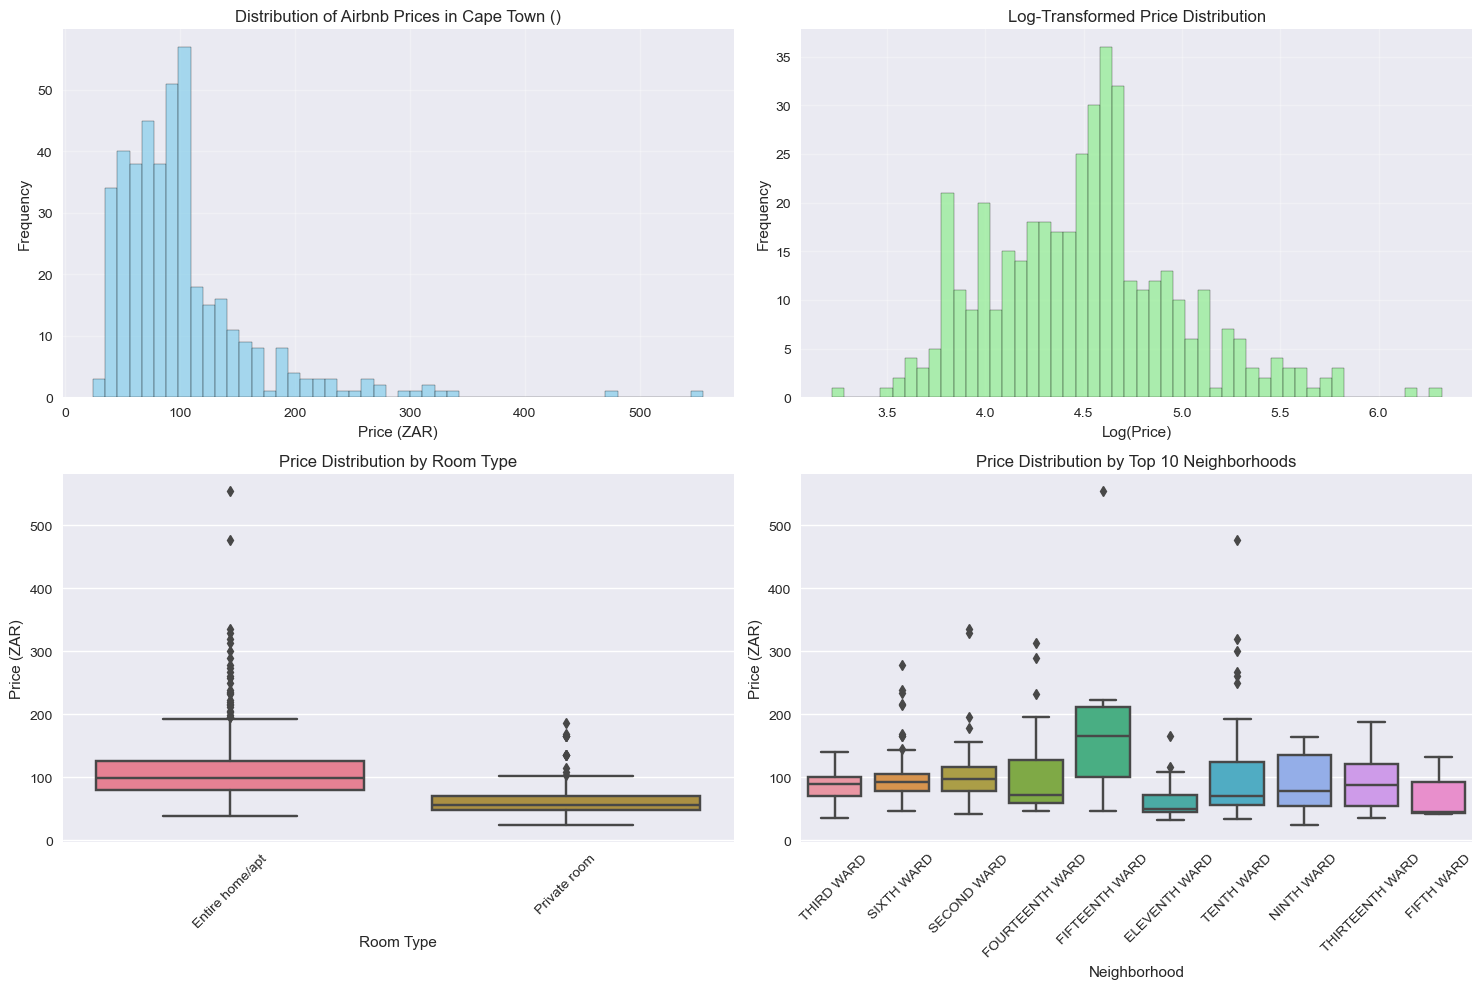

count    420.000000
mean     101.300000
std       59.917449
min       24.000000
25%       64.000000
50%       90.500000
75%      114.000000
max      555.000000
Name: price, dtype: float64
• Average price: ZAR 101.30
• Median price: ZAR 90.50
• Most common price range: ZAR 64.00 - ZAR 114.00


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original price distribution
axes[0,0].hist(listings_clean['price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Airbnb Prices in Cape Town ()')
axes[0,0].set_xlabel('Price (ZAR)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

# Log transformation for normality
listings_clean['log_price'] = np.log1p(listings_clean['price'])
axes[0,1].hist(listings_clean['log_price'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Log-Transformed Price Distribution')
axes[0,1].set_xlabel('Log(Price)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# Price by room type
sns.boxplot(data=listings_clean, x='room_type', y='price', ax=axes[1,0])
axes[1,0].set_title('Price Distribution by Room Type')
axes[1,0].set_xlabel('Room Type')
axes[1,0].set_ylabel('Price (ZAR)')
axes[1,0].tick_params(axis='x', rotation=45)

# Price by neighborhood (top 10 only)
top_neighborhoods = listings_clean['neighbourhood_cleansed'].value_counts().head(10).index
neighborhood_data = listings_clean[listings_clean['neighbourhood_cleansed'].isin(top_neighborhoods)]
sns.boxplot(data=neighborhood_data, x='neighbourhood_cleansed', y='price', ax=axes[1,1])
axes[1,1].set_title('Price Distribution by Top 10 Neighborhoods')
axes[1,1].set_xlabel('Neighborhood')
axes[1,1].set_ylabel('Price (ZAR)')

axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Key Statistical Summary"
print(listings_clean['price'].describe())

print(f"• Average price: ZAR {listings_clean['price'].mean():.2f}")
print(f"• Median price: ZAR {listings_clean['price'].median():.2f}")
print(f"• Most common price range: ZAR {listings_clean['price'].quantile(0.25):.2f} - ZAR {listings_clean['price'].quantile(0.75):.2f}")


#### Subplot Explanation

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

**Top-Left: Raw Price Distribution**
- Highly right-skewed distribution with extreme outliers
- Majority of listings cluster at lower price points (ZAR 0-5,000), with luxury properties creating long tail

**Top-Right: Log-Transformed Prices**
- Log transformation creates near-normal distribution
- Essential for linear models that assume normality, reduces outlier influence on predictions

**Bottom-Left: Price by Room Type**
- Entire homes/apartments command premium prices vs private/shared rooms
- Clear pricing tiers by room category inform host positioning strategies

**Bottom-Right: Top 10 Neighborhood Prices**
- Significant neighborhood-based price variation exists
- Location is a primary pricing driver, enables targeted market positioning

**Key Statistical Summary**
- **Average Price**: ZAR 2,704.25
- **Median Price**: ZAR 1,509.00
- **Price Range**: ZAR 161 - ZAR 28,286
- **Most Common Range**: ZAR 950 - ZAR 2,898 (25th-75th percentile)

</div>

### Numerical Feature Analysis

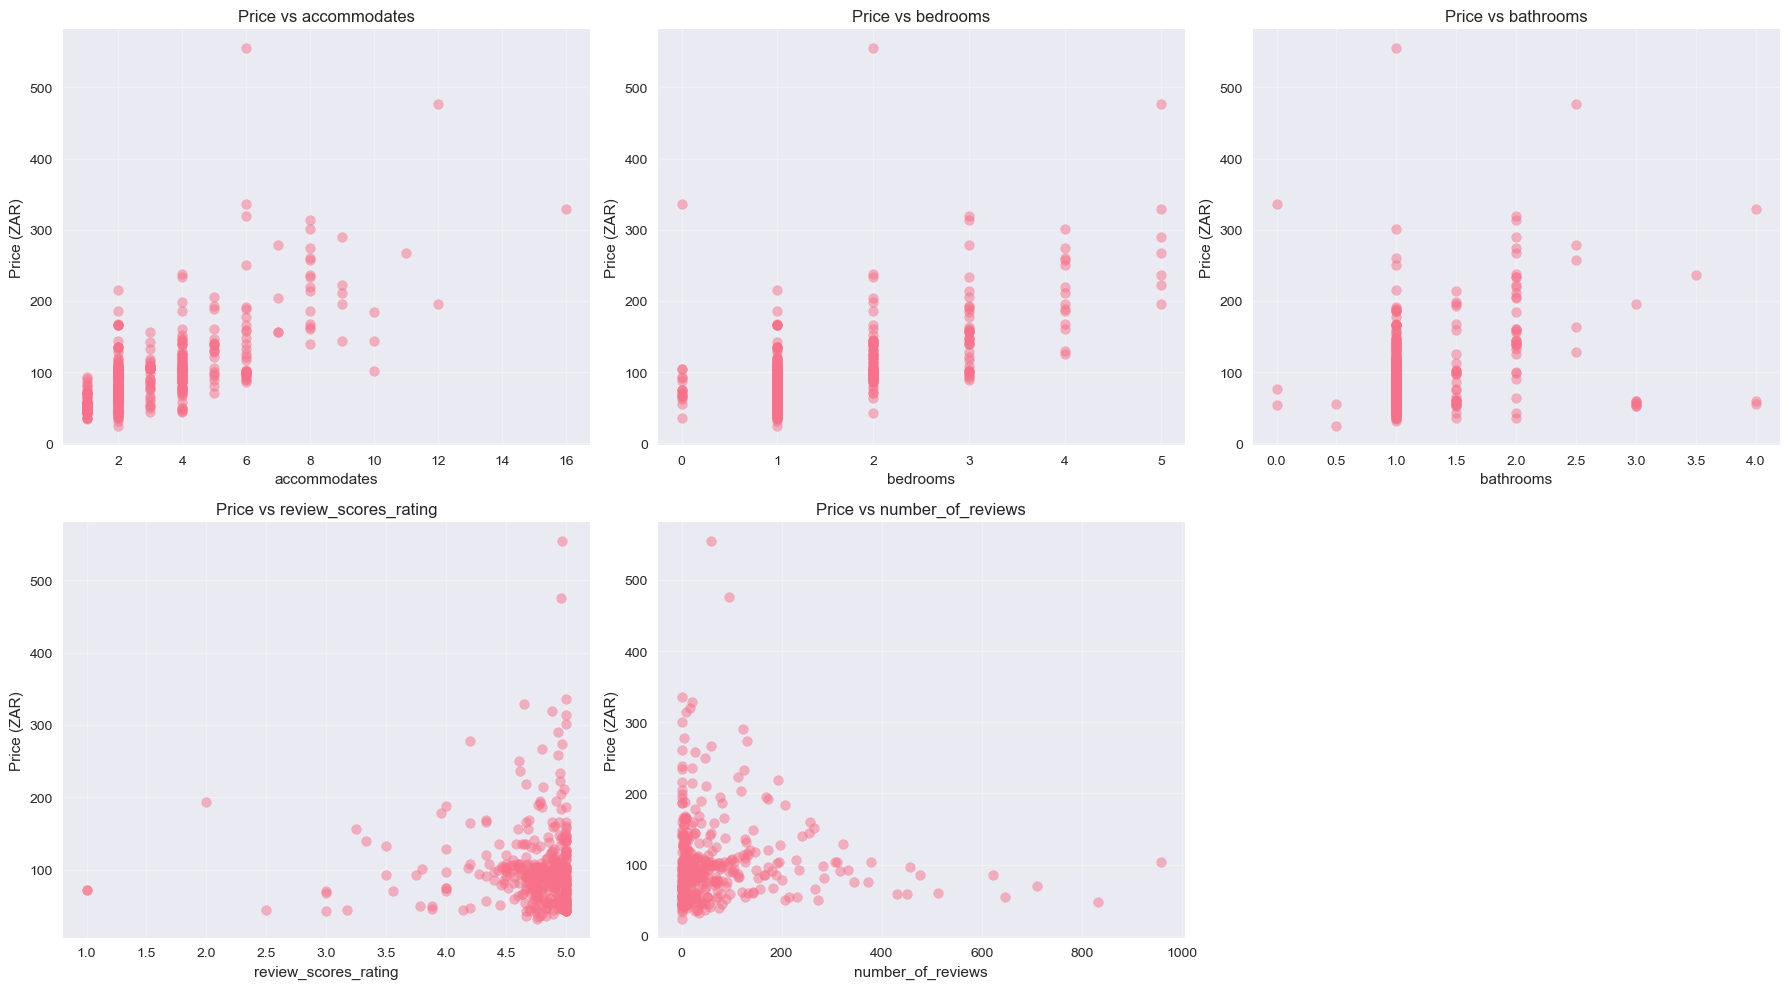

In [11]:
# Select key numerical features for analysis
numerical_features = ['accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating', 'number_of_reviews']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, feature in enumerate(numerical_features):
    row, col = i // 3, i % 3
    if feature in listings_clean.columns:
        axes[row, col].scatter(listings_clean[feature], listings_clean['price'], alpha=0.5)
        axes[row, col].set_xlabel(feature)
        axes[row, col].set_ylabel('Price (ZAR)')
        axes[row, col].set_title(f'Price vs {feature}')
        axes[row, col].grid(True, alpha=0.3)

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

#### Numerical Feature Correlations with Price
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

**Capacity Features**
- **Accommodates**: Strong positive correlation with diminishing returns
  - Prices increase with guest capacity but plateau after 6-10 guests
  - High variability at each capacity level indicates other factors at play

- **Bedrooms & Bathrooms**: Positive but nonlinear relationships
  - Significant price increases from 0→3 bedrooms/bathrooms
  - Minimal additional premium beyond 3-4 units
  - Extreme values (20-50) likely data errors requiring treatment

**Review & Reputation Features**
- **Review Scores Rating**: Weak to moderate positive correlation
  - Dense clustering at high ratings (4.8-5.0) with wide price dispersion
  - Lower ratings (<3.5) consistently associate with lower prices
  - Suggests rating acts as quality floor rather than premium driver

- **Number of Reviews**: Strong negative correlation
  - Higher review counts associate with lower-priced listings
  - Expensive properties have fewer reviews (newer listings or lower occupancy)
  - Implies established, budget-friendly listings accumulate more reviews

**Data Quality & Transformation Requirements**
- **Outlier Treatment**: Extreme values in bedrooms/bathrooms need capping or removal
- **Log Transformation**: Required for number_of_reviews and price variables
- **Non-linear Modeling**: Diminishing returns suggest need for polynomial terms or tree-based models
- **Feature Engineering**: Consider creating "premium bathroom/bedroom" flags for counts >3

**Business Implications**
- **Pricing Strategy**: Capacity drives base pricing but has natural limits
- **Quality Perception**: High ratings necessary but not sufficient for premium pricing
- **Market Dynamics**: Established budget listings dominate review volume, luxury segment has lower turnover

</div>

### Categorical Feature Analysis

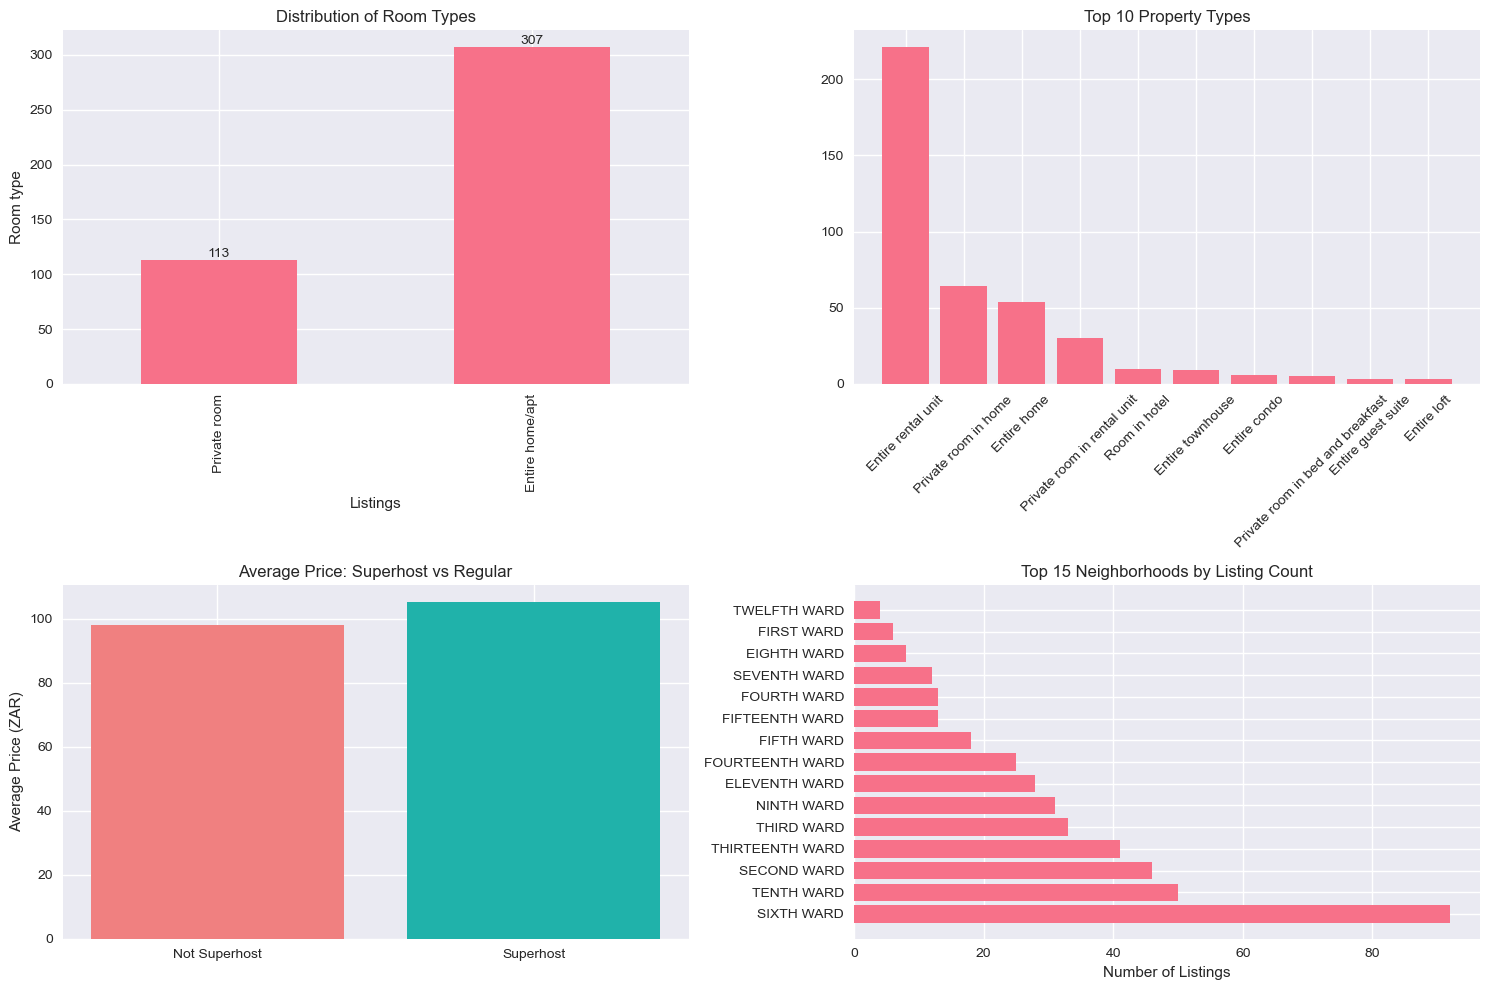

In [12]:
room_type_counts = listings_clean['room_type'].value_counts()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Room type distribution
ax = axes[0,0]
room_type_counts.sort_values().plot(kind='bar', ax=ax)
ax.bar_label(ax.containers[0], fmt='%d')
ax.set_xlabel('Listings')
ax.set_ylabel('Room type')
ax.set_title('Distribution of Room Types')



# Property type (top 10 only)
property_type_counts = listings_clean['property_type'].value_counts().head(10)
axes[0,1].bar(property_type_counts.index, property_type_counts.values)
axes[0,1].set_title('Top 10 Property Types')
axes[0,1].tick_params(axis='x', rotation=45)

# Superhost impact
superhost_price = listings_clean.groupby('host_is_superhost')['price'].mean()
axes[1,0].bar(['Not Superhost', 'Superhost'], superhost_price.values, color=['lightcoral', 'lightseagreen'])
axes[1,0].set_title('Average Price: Superhost vs Regular')
axes[1,0].set_ylabel('Average Price (ZAR)')

# Neighborhood count (top 15)
neighborhood_counts = listings_clean['neighbourhood_cleansed'].value_counts().head(15)
axes[1,1].barh(neighborhood_counts.index, neighborhood_counts.values)
axes[1,1].set_title('Top 15 Neighborhoods by Listing Count')
axes[1,1].set_xlabel('Number of Listings')

plt.tight_layout()
plt.show()

#### Categorical Feature Analysis
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

**Room Type Distribution**
- Entire home/apartment (18,844 listings, ~85% of market)
- Private rooms (3,298 listings)
- Hotel rooms (66) and Shared rooms (43) represent specialty offerings
- **Implication**: Platform heavily skewed toward full-property rentals vs shared accommodations

**Property Type Diversity**
- Entire rental units, entire homes, and entire condos dominate
- **Specialty Properties**: Villas, guest suites, serviced apartments represent premium segments
- **Market Fragmentation**: 75+ property types total, with top 10 covering majority of listings
</div>
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Host Status Impact
- Superhosts average ZAR 2,660 vs ZAR 2,700 for regular hosts
- **Interpretation**: Superhost status correlates with competitive pricing strategy rather than premium pricing
- **Business Insight**: Superhost designation emphasizes occupancy and quality over price maximization
</div>
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Geographic Distribution
- Top 15 wards contain bulk of listings
- Ward 115 (5,000 listings) and Ward 54 (3,400 listings) dominate
- **Long Tail**: Significant drop-off after top 2 neighborhoods

</div>
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Modeling Implications

##### **Feature Engineering Requirements**
```python
# Required preprocessing steps:
- Room type: Consider binary encoding (entire_home vs not)
- Property type: Group rare categories into 'Other'
- Neighborhood: Use target encoding for high-cardinality wards
- Superhost: Explore interaction terms with review metrics
```

</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Validation Strategy
- **Spatial Cross-Validation**: Prevent data leakage between neighborhoods
- **Stratified Sampling**: Maintain room type and property type distributions
- **Geographic Grouping**: Consider ward-based splits for robust evaluation

#### Business Strategy Insights
- **Market Positioning**: Entire home rentals represent core competitive landscape
- **Pricing Strategy**: Superhost status doesn't command price premium alone
- **Geographic Focus**: Top neighborhoods offer largest competitive datasets for reliable modeling
</div>

### Correlation Analysis

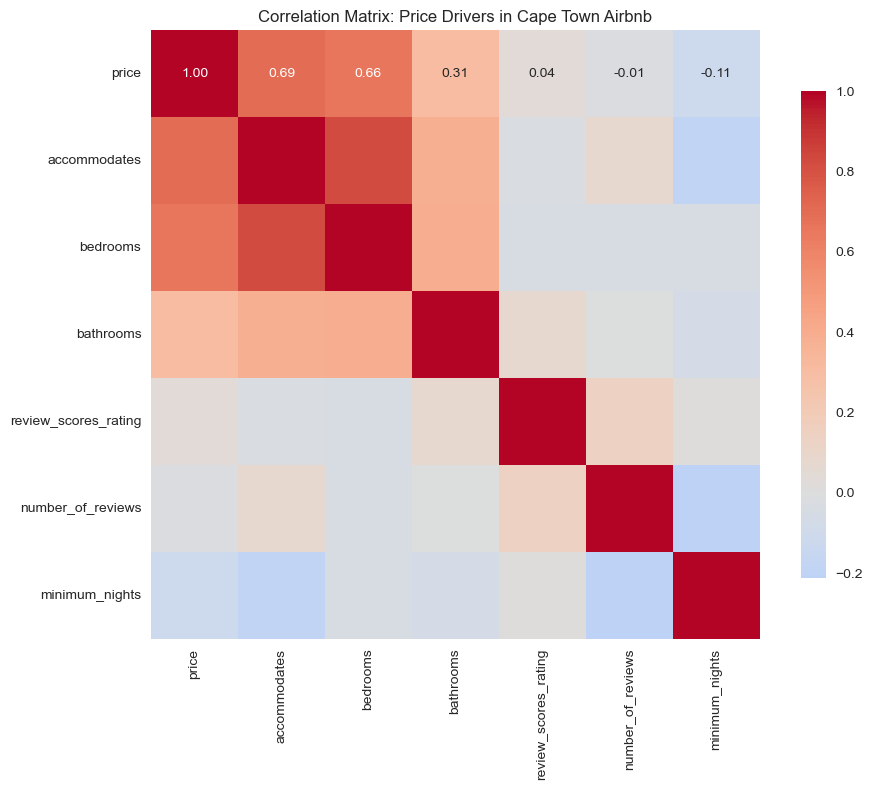

In [13]:
# Select numerical features for correlation matrix
corr_features = ['price', 'accommodates', 'bedrooms', 'bathrooms',
                 'review_scores_rating', 'number_of_reviews', 'minimum_nights']

corr_matrix = listings_clean[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Price Drivers in Cape Town Airbnb')
plt.tight_layout()
plt.show()

### Data Quality Assessment

In [14]:
missing_data = listings_clean[['price', 'bedrooms', 'bathrooms', 'review_scores_rating']].isnull().sum()
print("Missing values in key columns:")
for col, missing in missing_data.items():
    print(f"• {col}: {missing} missing ({missing/len(listings_clean)*100:.1f}%)")

Missing values in key columns:
• price: 0 missing (0.0%)
• bedrooms: 0 missing (0.0%)
• bathrooms: 0 missing (0.0%)
• review_scores_rating: 48 missing (11.4%)


<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 3. Data Preparation </h2>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

- **Purpose**: Transform raw data into a clean, structured format suitable for machine learning models through cleaning, feature engineering, and preprocessing.
- **Input**: listings_clean DataFrame from EDA
- **Output**: Cleaned, feature-engineered dataset ready for modeling
- **Dependencies**: EDA must be completed, listings_clean available

</div>

### 3.1 Data Cleaning
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Purpose:
 Transform raw data into a clean, structured format suitable for machine learning models through cleaning, feature engineering, and preprocessing.

First, I'll choose the columns that I'll most probably use in achieving my objective, which makes it easier to work in data preparation instead of using the entire dataset.
</div>

In [15]:
relevant_columns = ['property_type', 'room_type', 'accommodates', 'amenities', 'bedrooms', 'beds', 'bathrooms', 'latitude', 'longitude', 'neighbourhood_cleansed', 
                   'host_is_superhost', 'host_listings_count', 'host_since', 'host_acceptance_rate', 'availability_365', 'number_of_reviews', 
                   'review_scores_rating', 'instant_bookable', 'review_scores_location', 'price']

In [16]:
# Create a working copy to preserve original data
df = listings[relevant_columns]
df.head()

,property_type,room_type,accommodates,amenities,bedrooms,beds,bathrooms,latitude,longitude,neighbourhood_cleansed,host_is_superhost,host_listings_count,host_since,host_acceptance_rate,availability_365,number_of_reviews,review_scores_rating,instant_bookable,review_scores_location,price
0,Entire rental unit,Entire home/apt,4,"[""Smoke alarm"", ""Essentials"", ""Heating"", ""Wifi...",2.0,2.0,1.0,42.65789,-73.75370,THIRD WARD,f,1,2013-01-07,50%,159,9,3.56,f,3.22,70.0
1,Entire rental unit,Entire home/apt,3,"[""Smart lock"", ""HDTV with standard cable, Appl...",2.0,1.0,1.0,42.65222,-73.76724,SIXTH WARD,t,5,2014-08-07,100%,339,311,4.74,f,4.81,104.0
2,Entire rental unit,Entire home/apt,2,"[""Carbon monoxide alarm"", ""Dedicated workspace...",0.0,1.0,1.0,42.64615,-73.75966,SECOND WARD,f,2,2015-03-13,99%,16,372,4.52,f,4.76,75.0
3,Entire rental unit,Entire home/apt,2,"[""Carbon monoxide alarm"", ""Dedicated workspace...",1.0,1.0,1.0,42.65222,-73.76724,SIXTH WARD,t,5,2014-08-07,100%,348,332,4.73,f,4.80,92.0
4,Entire rental unit,Entire home/apt,4,"[""Window AC unit"", ""Carbon monoxide alarm"", ""H...",1.0,2.0,1.0,42.65559,-73.76506,SIXTH WARD,t,1,2014-07-07,100%,217,623,4.79,f,4.87,86.0


### 3.1.1 Handling Missing Values

In [17]:
df = df.dropna(subset = ['bedrooms', 'host_is_superhost', 'host_listings_count', 'host_since'])
df = df.reset_index(drop = True)
df.isna().sum()*100/len(df)

property_type              0.000000
room_type                  0.000000
accommodates               0.000000
amenities                  0.000000
bedrooms                   0.000000
beds                       7.268722
bathrooms                  7.268722
latitude                   0.000000
longitude                  0.000000
neighbourhood_cleansed     0.000000
host_is_superhost          0.000000
host_listings_count        0.000000
host_since                 0.000000
host_acceptance_rate       3.083700
availability_365           0.000000
number_of_reviews          0.000000
review_scores_rating      12.775330
instant_bookable           0.000000
review_scores_location    12.775330
price                      7.268722
dtype: float64

In [18]:
# Handle the missing in host_acceptance_rate
# It's categorical data, so I'll fill the missing values with the mode
df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mode()[0], inplace = True)

In [19]:
df.isna().sum()*100/len(df)

property_type              0.000000
room_type                  0.000000
accommodates               0.000000
amenities                  0.000000
bedrooms                   0.000000
beds                       7.268722
bathrooms                  7.268722
latitude                   0.000000
longitude                  0.000000
neighbourhood_cleansed     0.000000
host_is_superhost          0.000000
host_listings_count        0.000000
host_since                 0.000000
host_acceptance_rate       0.000000
availability_365           0.000000
number_of_reviews          0.000000
review_scores_rating      12.775330
instant_bookable           0.000000
review_scores_location    12.775330
price                      7.268722
dtype: float64

The remaining missing values are floats. I have to determine if the data in those columns are skewed so that I'll known which method to use in order to fill their missing values.

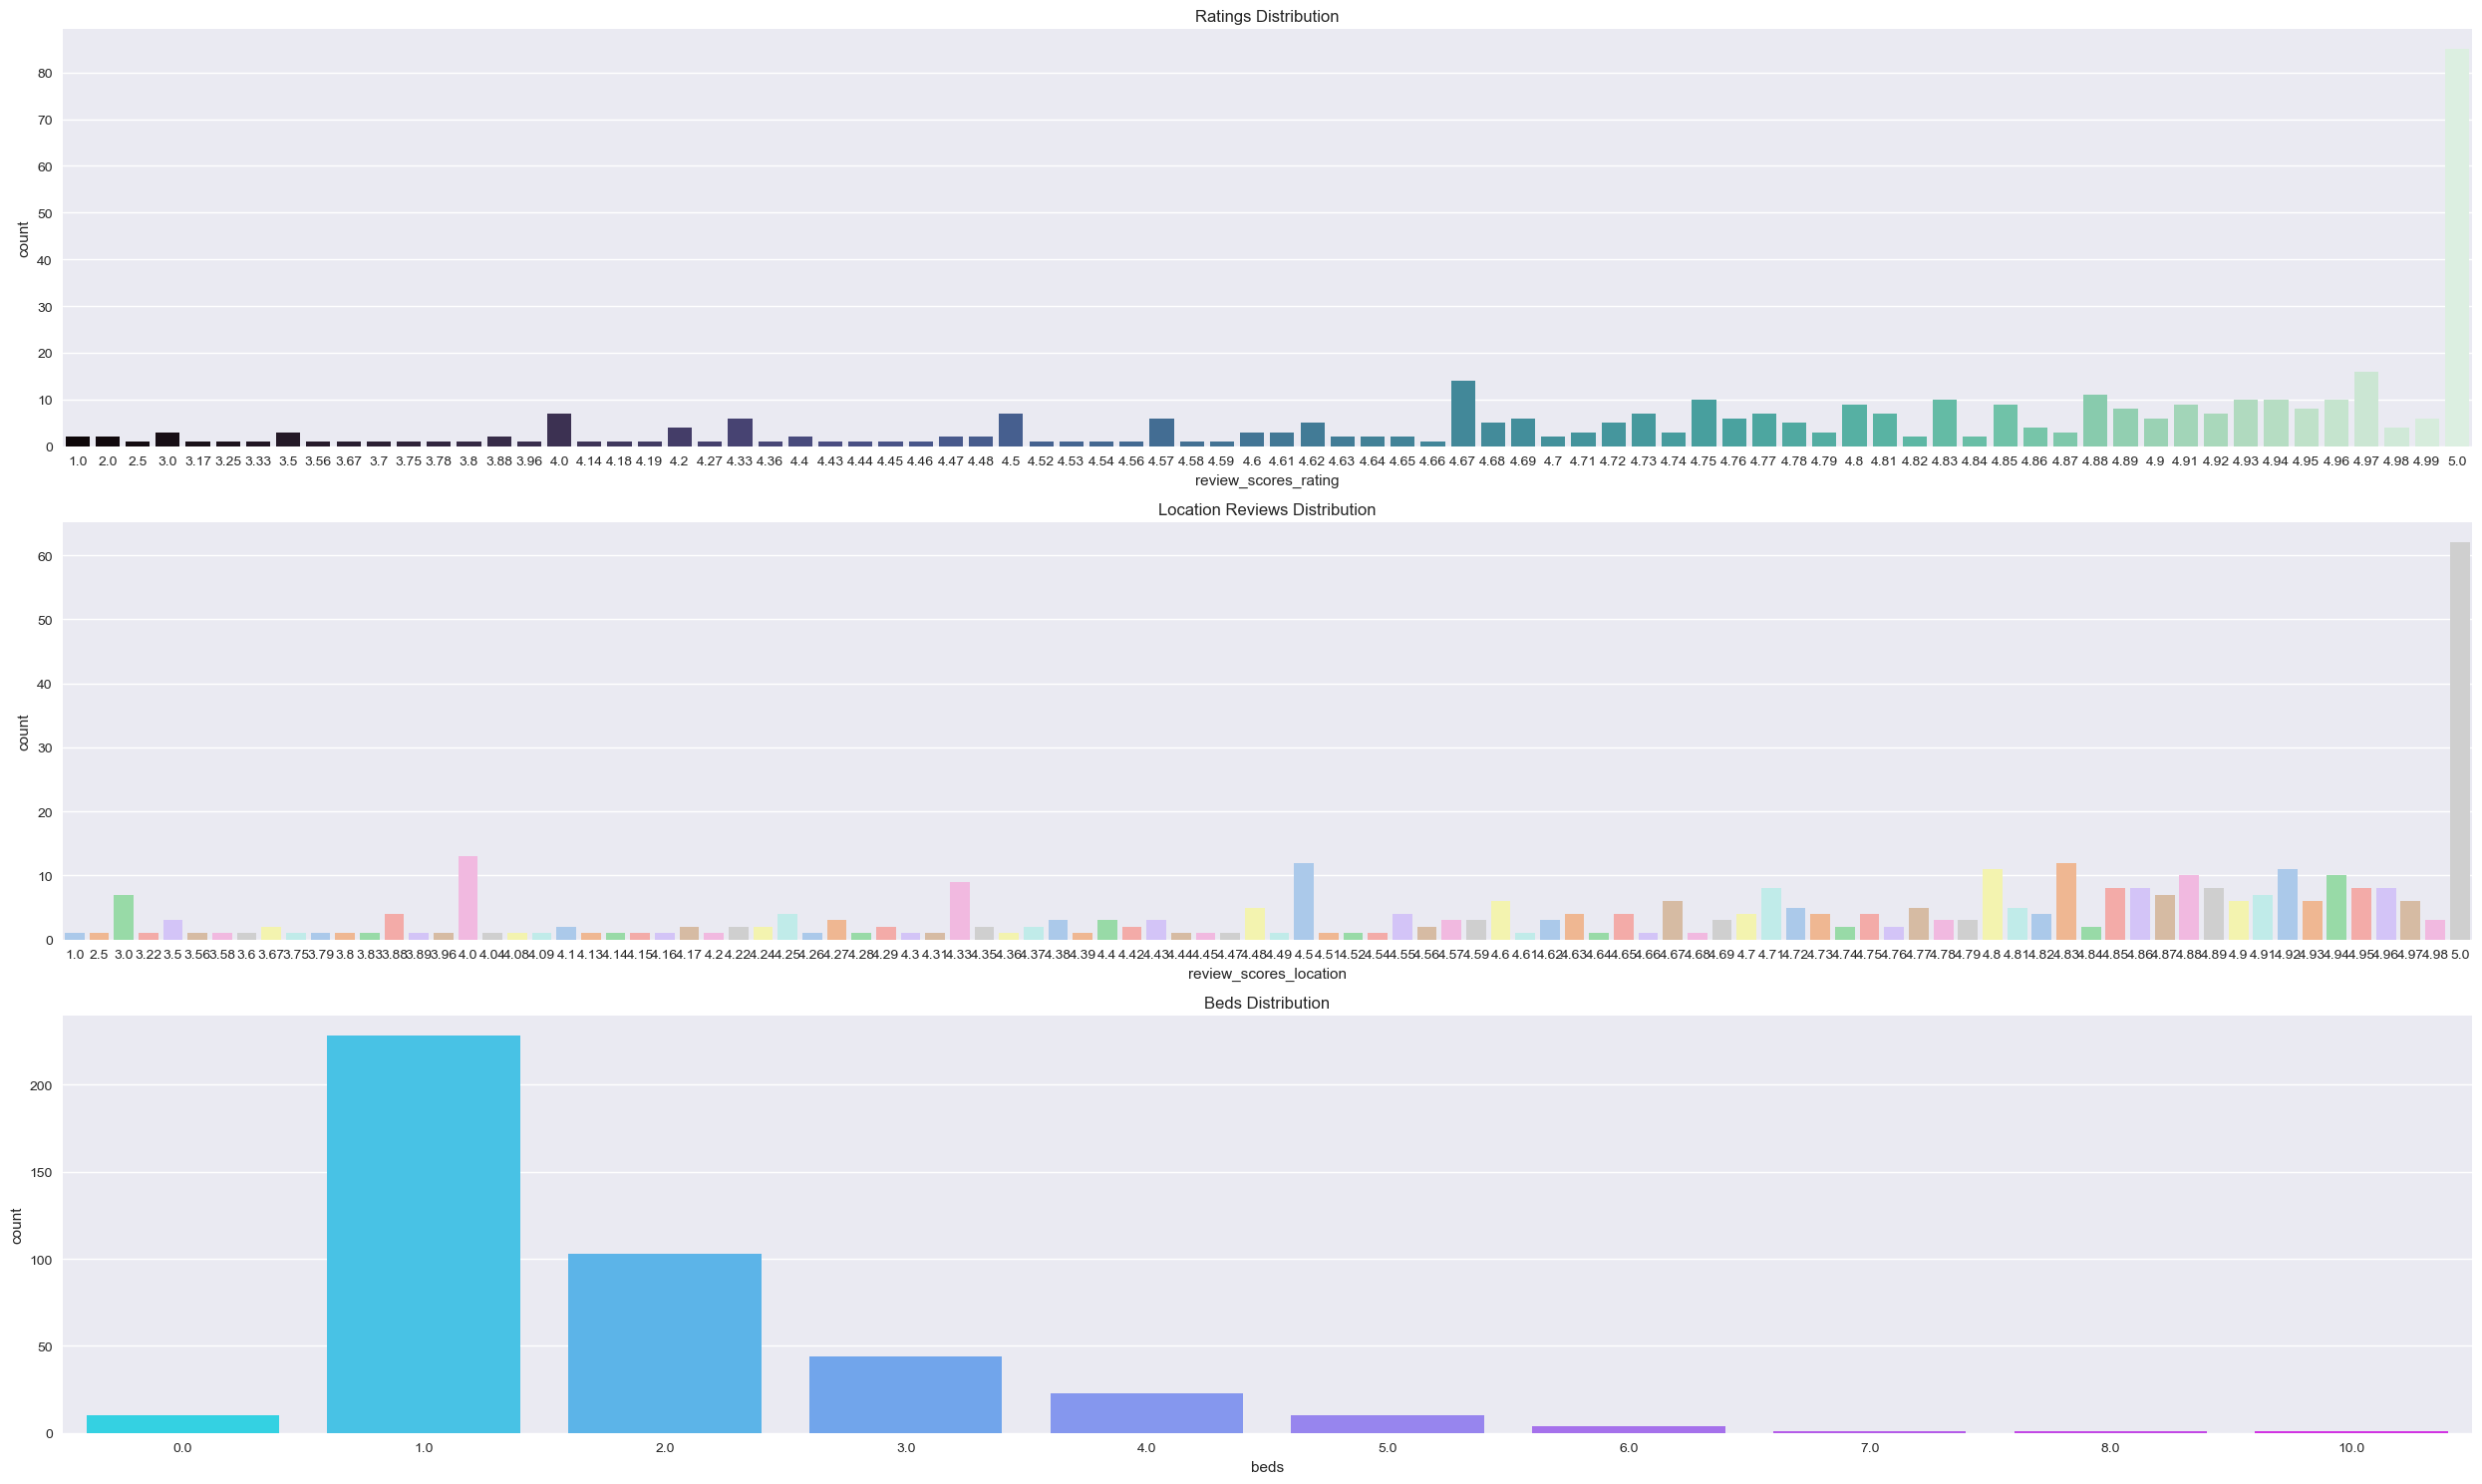

In [20]:
# Checking how the dta is distributed
fig, axes = plt.subplots(3, 1, figsize=(25, 15))
sns.countplot(x='review_scores_rating', data=listings, ax=axes[0], palette='mako')
sns.countplot(x='review_scores_location', data=listings, ax=axes[1], palette='pastel')
sns.countplot(x='beds', data=listings, ax=axes[2], palette='cool')
axes[0].set_title('Ratings Distribution')
axes[1].set_title('Location Reviews Distribution')
axes[2].set_title('Beds Distribution')
plt.tight_layout()
plt.show()

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Observation

The graphs may not be fully clear due to their large amount, but from what is visible, one can see that rating and location reviews are skewed to the right, while beds is skewed to the left, which means that I'll use the median to fill the missing values. Bathrooms and price underwent some analysis in the data understanding, but they're also skewed to the left.
</div>

In [21]:
cols = ['beds', 'review_scores_rating', 'bathrooms', 'review_scores_location', 'price'] 

# Fill the each column with its median
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

In [22]:
df.isna().sum()*100/len(df)

property_type             0.0
room_type                 0.0
accommodates              0.0
amenities                 0.0
bedrooms                  0.0
beds                      0.0
bathrooms                 0.0
latitude                  0.0
longitude                 0.0
neighbourhood_cleansed    0.0
host_is_superhost         0.0
host_listings_count       0.0
host_since                0.0
host_acceptance_rate      0.0
availability_365          0.0
number_of_reviews         0.0
review_scores_rating      0.0
instant_bookable          0.0
review_scores_location    0.0
price                     0.0
dtype: float64

#### Strategic Data Imputation

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**Property Features** → Median Imputation
- Bedrooms, bathrooms, beds: Structural attributes with predictable ranges
- Preserves dataset size while maintaining data integrity

**Host Behavior** → Row Removal  
- `host_response_rate`: Critical metric for host quality assessment
- Removes incomplete records to ensure reliable analysis

**Review Metrics** → Column-specific Median
- All review score dimensions (accuracy, cleanliness, communication, etc.)
- Maintains rating scale consistency across all review categories
</div>

### 3.1.2 Data Type Standardization
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
Some features such as bedrooms need to be well formatted. For this example, bedrooms are not calculated by floats, is, half a bedroom (2.5), so I need to change it to an integer.
</div>

In [23]:
# Change the below columns from floats to integers
format_cols = ['bedrooms', 'beds', 'bathrooms']

df[format_cols] = df[format_cols].astype('int64')

In [24]:
df.dtypes

property_type              object
room_type                  object
accommodates                int64
amenities                  object
bedrooms                    int64
beds                        int64
bathrooms                   int64
latitude                  float64
longitude                 float64
neighbourhood_cleansed     object
host_is_superhost          object
host_listings_count         int64
host_since                 object
host_acceptance_rate       object
availability_365            int64
number_of_reviews           int64
review_scores_rating      float64
instant_bookable           object
review_scores_location    float64
price                     float64
dtype: object

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Integer Format Standardization
- **Columns**: `bedrooms`, `beds`, `bathrooms`
- **Transformation**: Float numbers → Integer values
- **Impact**: Ensures realistic property measurements (no half-bedrooms) and prepares data for machine learning algorithms that require whole numbers

**Result**: All three columns now show as `int64` data type, confirming successful conversion from floating-point numbers to whole integers that accurately represent real-world property features.
</div>

### 3.1.3 Dealing with outliers

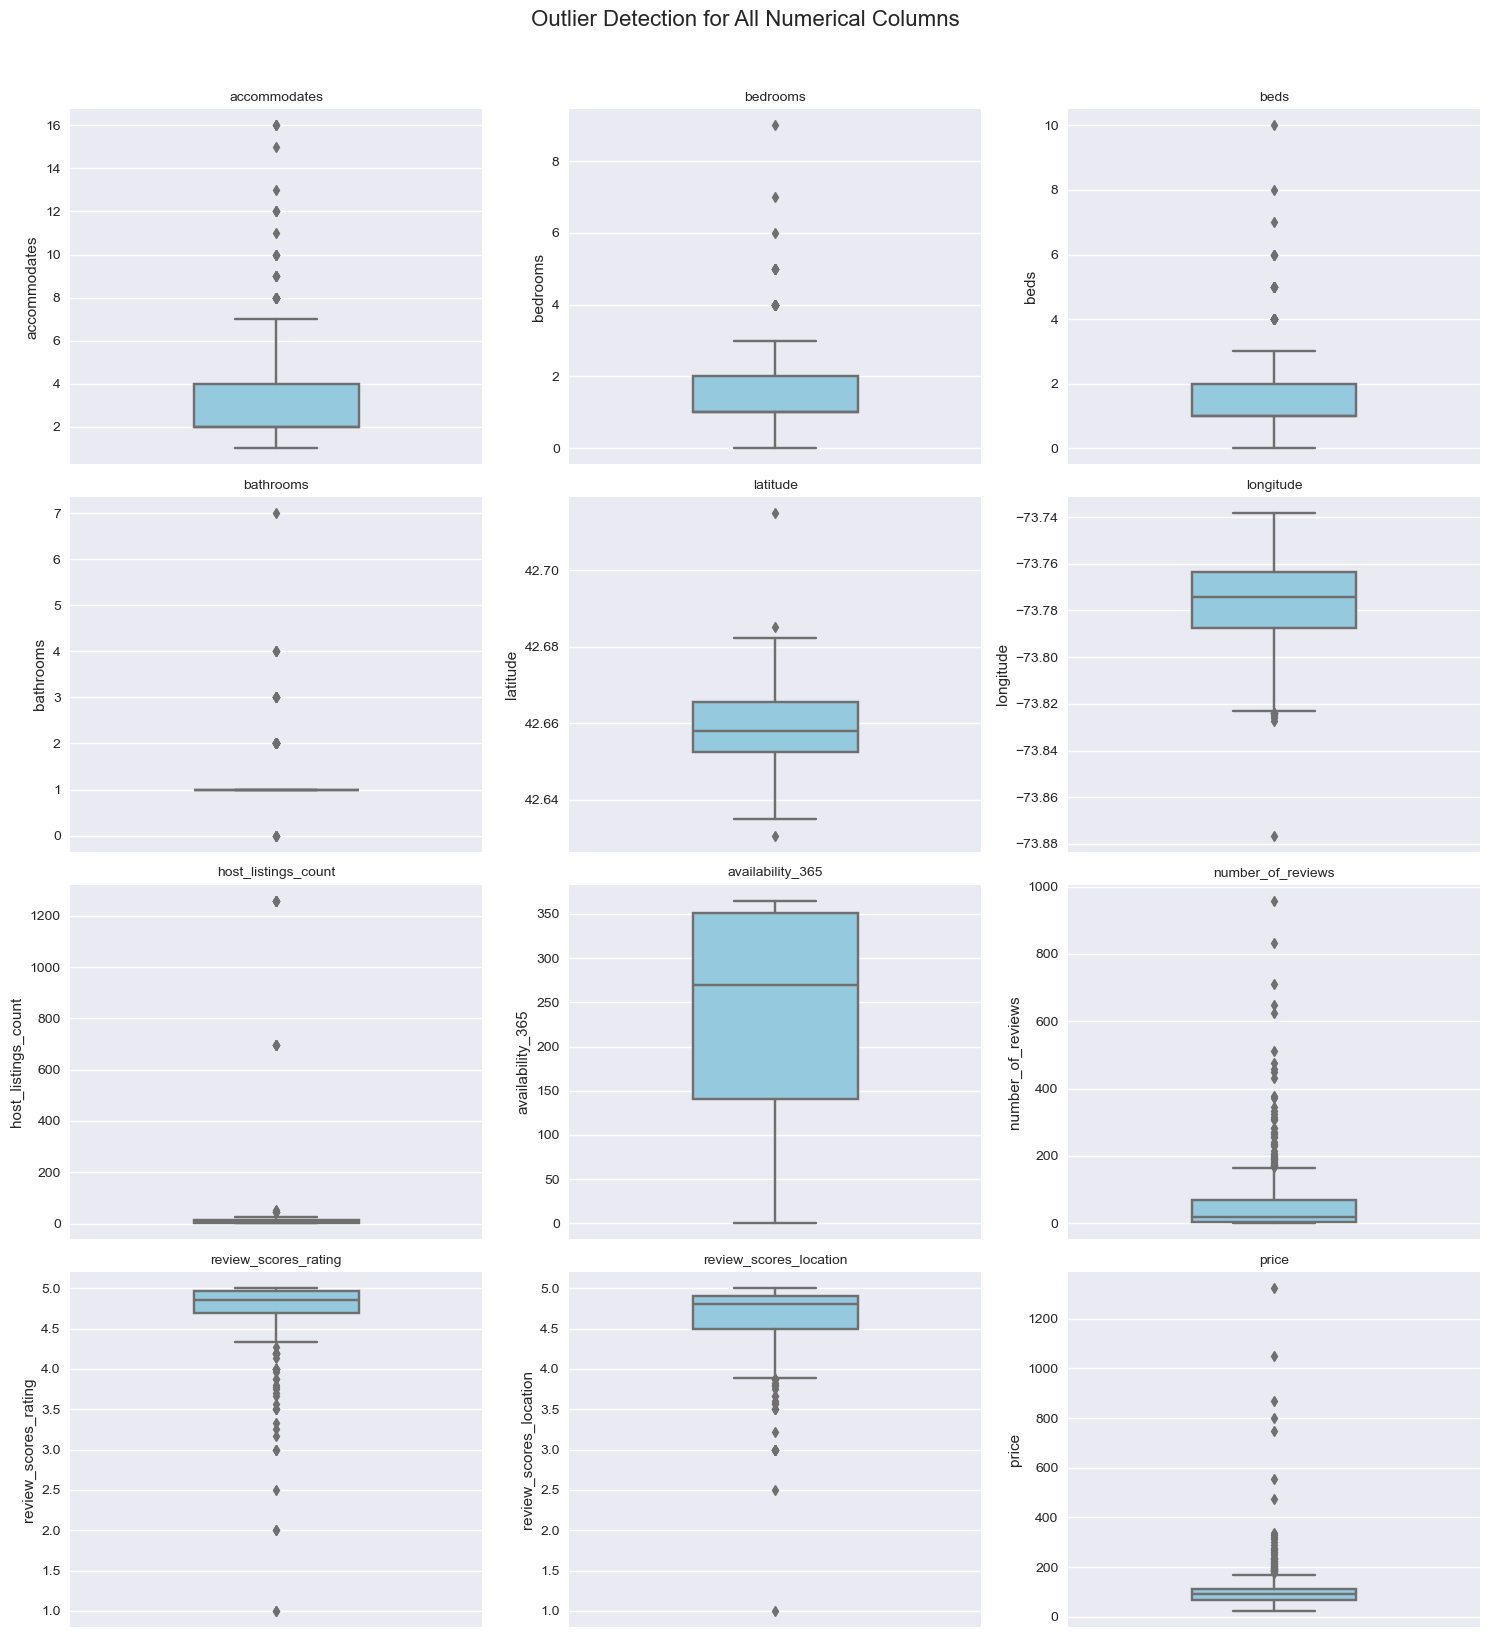

In [25]:
# Select only numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Set figure size dynamically based on number of columns
n_cols = 3  # number of plots per row
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(15, n_rows * 4))
plt.suptitle('Outlier Detection for All Numerical Columns', fontsize=16, y=1.02)

# Create a boxplot for each numeric column
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='skyblue', width=0.4)
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.tight_layout()

plt.show()

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Observation
There are several outliers in each column.
</div>

In [26]:
# Check for the percentages of the outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of data that are outliers: {len(outliers) / len(df) * 100:.2f}%")

Number of outliers: 42
Percentage of data that are outliers: 9.25%


In [27]:
# Check some of the outliers and see if they are genuine outliers or mistakes made, eg, in inputting data.
outliers.sort_values(by='price', ascending=False).head(10)

,property_type,room_type,accommodates,amenities,bedrooms,beds,bathrooms,latitude,longitude,neighbourhood_cleansed,host_is_superhost,host_listings_count,host_since,host_acceptance_rate,availability_365,number_of_reviews,review_scores_rating,instant_bookable,review_scores_location,price
124,Entire home,Entire home/apt,12,"[""Bluetooth sound system"", ""Pool table"", ""Exte...",4,4,3,42.667620,-73.799190,FOURTEENTH WARD,t,18,2021-01-04,100%,320,17,4.94,f,4.88,1322.0
129,Entire rental unit,Entire home/apt,4,"[""TRESemm\u00e9 conditioner"", ""Babysitter reco...",1,1,1,42.645351,-73.753647,SECOND WARD,f,3,2020-02-13,100%,365,10,3.70,f,3.60,1050.0
244,Entire home,Entire home/apt,16,"[""Exterior security cameras on property"", ""Car...",9,10,4,42.669899,-73.797703,THIRTEENTH WARD,t,18,2021-01-04,100%,334,0,4.85,f,4.80,869.0
168,Entire home,Entire home/apt,15,"[""Smart lock"", ""Carbon monoxide alarm"", ""Dedic...",7,8,7,42.656329,-73.775205,NINTH WARD,f,7,2023-01-02,85%,63,7,4.57,t,4.71,800.0
24,Entire home,Entire home/apt,10,"[""Smart lock"", ""Exterior security cameras on p...",4,5,1,42.675470,-73.824020,FIFTEENTH WARD,t,8,2012-11-27,88%,364,9,5.00,f,5.00,749.0
16,Entire home,Entire home/apt,6,"[""Baby safety gates"", ""Barbecue utensils"", ""Ou...",2,3,1,42.676370,-73.823950,FIFTEENTH WARD,t,8,2012-11-27,88%,365,58,4.97,f,4.97,555.0
101,Entire home,Entire home/apt,12,"[""Smart lock"", ""Carbon monoxide alarm"", ""Dedic...",5,7,2,42.662360,-73.792450,TENTH WARD,t,23,2018-12-28,96%,251,95,4.96,f,4.92,476.0
342,Entire rental unit,Entire home/apt,6,"[""Wifi"", ""Pool table"", ""Exterior security came...",0,2,0,42.644575,-73.756684,SECOND WARD,f,1,2024-04-10,42%,364,1,5.00,f,5.00,336.0
259,Entire townhouse,Entire home/apt,16,"[""Paid parking on premises"", ""Smart lock"", ""Ex...",5,5,4,42.644180,-73.753160,SECOND WARD,t,15,2015-09-17,99%,342,20,4.65,t,4.70,329.0
219,Entire guesthouse,Entire home/apt,6,"[""Dedicated workspace"", ""Hangers"", ""Hot water ...",3,4,2,42.660360,-73.772900,TENTH WARD,f,12,2023-07-17,98%,55,17,4.88,t,4.82,320.0


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Observation
Some of the outliers are not genuine while others are. How can an entire villa or home not have any bedrooms but have 10 beds, this is a good example of a non-genuine outlier. An example of a genuine outlier is 4 accommodates, 2 bedrooms, 2 beds and 2 bathrooms.
</div>

Capped extreme 1% outliers: prices below 68.00 set to lower cap, above 646.18 set to upper cap.


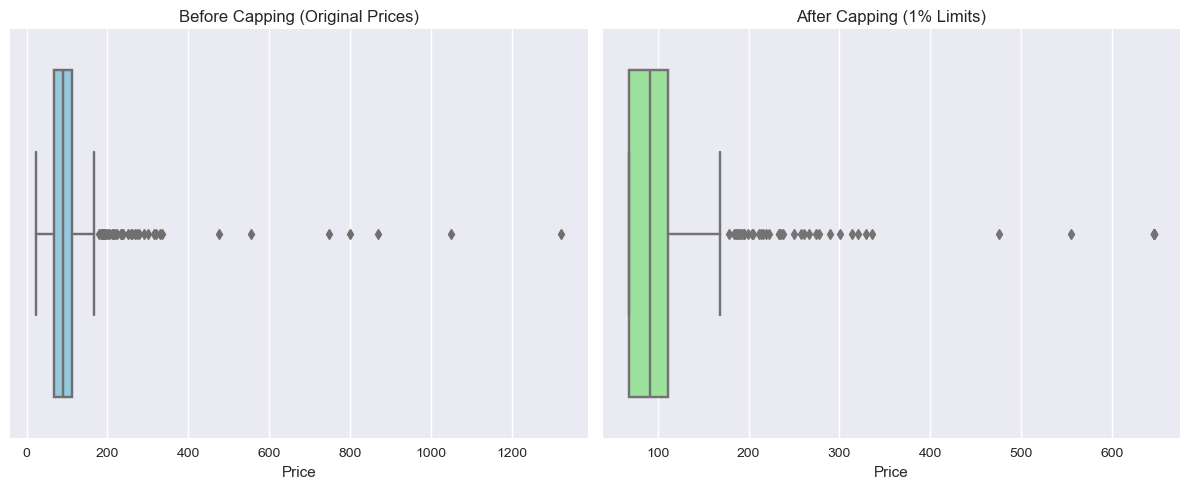

In [28]:
# Visualize original price distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Before Capping (Original Prices)')
plt.xlabel('Price')

# Cap extreme 1% outliers
lower_cap = df['price'].quantile(0.25)
upper_cap = df['price'].quantile(0.99)

df['price'] = np.where(
    df['price'] < lower_cap, lower_cap,
    np.where(df['price'] > upper_cap, upper_cap, df['price'])
)

print(f"Capped extreme 1% outliers: prices below {lower_cap:.2f} set to lower cap, above {upper_cap:.2f} set to upper cap.")

# Visualize capped prices
plt.subplot(1,2,2)
sns.boxplot(x=df['price'], color='lightgreen')
plt.title('After Capping (1% Limits)')
plt.xlabel('Price')

plt.tight_layout()
plt.show()

In [29]:
# Remove outliers for the rest of the other numerical columns
outlier_columns = ['accommodates', 'bedrooms', 'bathrooms', 'beds']

for col in outlier_columns:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers before capping
        outliers_high = (df[col] > upper_bound).sum()
        outliers_low = (df[col] < lower_bound).sum()
        total_outliers = outliers_high + outliers_low
        
        # Cap outliers instead of removing to preserve data
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        
        print(f"{col}: {total_outliers} outliers capped using the IQR method")

accommodates: 33 outliers capped using the IQR method
bedrooms: 30 outliers capped using the IQR method
bathrooms: 56 outliers capped using the IQR method
beds: 40 outliers capped using the IQR method


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### IQR-Based Outlier Capping

- **Features Treated**: `accommodates`, `bedrooms`, `bathrooms`, `beds`
- **Method**: Interquartile Range (IQR) with 1.5x multiplier
- **Approach**: Capping rather than removal to preserve data volume
- **Benefit**: Reduces skewness while maintaining dataset integrity

#### Technical Implementation**
- Upper/lower bounds calculated using Q1 - 1.5\*IQR and Q3 + 1.5*IQR
- Extreme values capped at these boundaries
- Preserves statistical relationships while mitigating outlier influence

#### Benefits
- **Data preservation:** No observations are removed, maintaining the dataset’s integrity.
- **Improved model stability:** Reduces the influence of extreme values on model training.
- **Enhanced reliability:** Produces a more balanced distribution of data without introducing bias.
</div>

### 3.1.4 Handling placeholders.

In [30]:
# Check for placeholders in the values of each column
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

property_type: ['Entire rental unit' 'Private room in rental unit'
 'Private room in guest suite' 'Entire place' 'Private room in home'
 'Entire home' 'Entire guest suite' 'Entire loft' 'Room in aparthotel'
 'Entire condo' 'Entire townhouse' 'Entire vacation home' 'Entire cottage'
 'Private room in bed and breakfast' 'Private room in townhouse'
 'Room in hotel' 'Entire guesthouse' 'Private room in villa'
 'Private room in guesthouse' 'Private room in condo']
room_type: ['Entire home/apt' 'Private room']
accommodates: [4. 3. 2. 1. 7. 6. 5.]
amenities: ['["Smoke alarm", "Essentials", "Heating", "Wifi", "Air conditioning", "Carbon monoxide alarm", "TV with standard cable", "Kitchen"]'
 '["Smart lock", "HDTV with standard cable, Apple TV", "Carbon monoxide alarm", "Dedicated workspace", "Hangers", "Toaster", "Smoke alarm", "Essentials", "Freezer", "Shampoo", "Self check-in", "Dishes and silverware", "Stove", "Coffee", "Conditioner", "Refrigerator", "Baking sheet", "Wifi", "Dining table", "

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Observation
  
No placeholders found after going through each columns and its unique values.
</div>

### 3.2 Advanced Feature Engineering
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### What to Do:

- Create new features that capture domain knowledge:
- Geospatial features (distance to landmarks, neighborhood clusters)
- Temporal features (seasonality, time-based patterns)
- Amenity analysis (counts, premium amenities, unique combinations)
- Host experience metrics (days hosting, response efficiency)
- Text-based features (description length, sentiment, keywords)

#### Feature Engineering Categories:
- **Geospatial**: Distance to V&A Waterfront, Table Mountain, beaches
- **Temporal**: High/low season indicators, month, day of week
- **Amenity-Based**: Luxury score, family-friendly score, business amenities
- **Host-Based**: Experience level, responsiveness metrics, superhost status
- **Property-Based**: Size metrics, quality indicators, unique selling points
</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### 3.2.1 Geospatial Features for Cape Town
- Defining key Cape Town landmarks (approximate coordinates) like table mountains and beaches
</div>

In [31]:
# Define the Haversine distance function, to make the distance calculated in kilometers.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Define major Cape Town landmarks
landmarks = {
    'table_mountain': (-33.9628, 18.4099),
    'v_a_waterfront': (-33.9056, 18.4218),
    'camps_bay': (-33.9508, 18.3786),
    'clifton_beach': (-33.9375, 18.3800),
    'city_center': (-33.9258, 18.4232)
}

# Calculate distance (in km) from each landmark
for name, (lat, lon) in landmarks.items():
    df[f'distance_from_{name}'] = haversine(df['latitude'], df['longitude'], lat, lon)

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Landmark Proximity Analysis
- **Key Landmarks**: Table Mountain, V&A Waterfront, Camps Bay, Clifton Beach, City Center
- **Distance Calculation**: Euclidean distance approximation (lat/long to km)
- **Business Value**: Proximity to attractions significantly influences pricing strategy

#### Technical Implementation
- Custom distance function using coordinate differences
- 111x multiplier for rough kilometer conversion from degree coordinates
- Creates 5 new distance features for spatial modeling
</div>

#### 3.2.2 Temporal Features from Host Experience
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

- Convert host_since to datetime and calculate hosting experience
</div>

In [32]:
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_days'] = (pd.Timestamp.now() - df['host_since']).dt.days
df['hosting_years'] = df['host_days'] / 365

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Host Experience Metrics
- **host_since**: Converted to datetime format for temporal analysis
- **host_experience_days**: Days since host joined platform (current date - host_since)
- **host_experience_years**: Years of hosting experience (days / 365.25)

#### Business Value
- **Experience Premium**: Quantifies host tenure as potential pricing factor
- **Trust Indicator**: Longer hosting history may correlate with pricing confidence
- **Market Knowledge**: Experienced hosts potentially better at optimizing prices
</div>

### 3.2.3 Amenity-Based Features

In [33]:
# Define a list of important (premium) amenities that may affect listing price
premium_amenities = [
    'Pool', 'Hot tub', 'Gym', 
    'BBQ grill', 'Ocean view', 'Wifi', 'Parking'
]

# Create a new binary column for each amenity (1 = has it, 0 = doesn't)
for amenity in premium_amenities:
    col_name = f'has_{amenity.lower().replace(" ", "_")}'
    df[col_name] = df['amenities'].astype(str).str.contains(amenity, case=False, na=False).astype('int64')

# Count how many total amenities each listing has
df['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Amenity Quantification
- **Total Count**: Parsed JSON amenities list to calculate total amenities per listing
- **Premium Flags**: Created binary indicators for 6 high-value amenities:
  - Pool, Hot tub, Gym, Air conditioning, BBQ grill, Ocean view

#### Business Impact
- **Amenity Premium**: Quantifies value of additional features and luxury offerings
- **Competitive Positioning**: Enables analysis of amenity-based pricing strategies
- **Feature Selection**: Identifies which amenities justify price premiums in Cape Town market
</div>

### 3.2.4 Host Experience

In [34]:
# Convert acceptance rate from string (%) to numeric
df['host_acceptance_rate'] = (
    df['host_acceptance_rate'].astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

# Map host_is_superhost (t/f) to numeric
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**Purpose:** 
Represents how responsive and reliable the host is. Superhosts with high acceptance rates tend to attract more bookings.
</div>

### 3.3 Feature Selection

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Approach
For selecting the most relevant predictors, I'll use **correlation analysis** to identify numerical features that are strongly related to the target variable, `price_capped`. This helps focus on variables that have the greatest impact on pricing. But first, I have to log tranform the target variable. `price`, in order to reduce skewness.
</div>

In [35]:
# Log-transform the target variable
df['log_price'] = np.log1p(df['price'])  # log(1 + price) to handle zero values

target_col = 'log_price'  

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlations with the target
correlations = numeric_df.corr(numeric_only=True)[target_col].sort_values(ascending=False)
# Display top correlated features
print("Top correlated features with target:\n")
print(correlations)

Top correlated features with target:

log_price                       1.000000
price                           0.921295
accommodates                    0.659012
bedrooms                        0.621809
beds                            0.601131
amenities_count                 0.242222
has_bbq_grill                   0.209497
has_gym                         0.099993
has_pool                        0.097540
hosting_years                   0.089730
host_days                       0.089730
distance_from_v_a_waterfront    0.078145
distance_from_city_center       0.078117
distance_from_clifton_beach     0.078062
distance_from_table_mountain    0.078052
distance_from_camps_bay         0.078042
host_acceptance_rate            0.057342
host_is_superhost               0.045346
host_listings_count             0.040116
has_hot_tub                     0.035565
review_scores_location          0.023709
has_parking                     0.018913
review_scores_rating            0.013949
availability_365   

In [36]:
# The final columns to use in achieving the objective
selected_features = [
    # Property characteristics
    'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    
    # Location Features
    'neighbourhood_cleansed', 'latitude', 'longitude',
    'dist_to_table_mountain', 'dist_to_v_a_waterfront'
    
    # Host Factors
    'host_is_superhost', 'host_listings_count',
    'host_acceptance_rate', 'hosting_years',
    
    # Review 
    'review_scores_rating', 'review_scores_location',
    
    # Amenities
    'amenities_count', 'has_pool',
    'has_bbq_grill', 'has_ocean_view', 'has_hot_tub',
    
    # Availability
    'instant_bookable'
]

# Filter to only include features that exist in our dataframe
available_features = [f for f in selected_features if f in df.columns]
print(f"Selected {len(available_features)} features for modeling:")
for feature in available_features:
    print(f"  • {feature}")

Selected 20 features for modeling:
  • property_type
  • room_type
  • accommodates
  • bedrooms
  • beds
  • bathrooms
  • neighbourhood_cleansed
  • latitude
  • longitude
  • host_listings_count
  • host_acceptance_rate
  • hosting_years
  • review_scores_rating
  • review_scores_location
  • amenities_count
  • has_pool
  • has_bbq_grill
  • has_ocean_view
  • has_hot_tub
  • instant_bookable


### Final Feature Selection

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Property Characteristics
- **Capacity**: `accommodates`, `bedrooms`, `beds`, `bathrooms`
- **Type**: `room_type`, `property_type`

**Geographic & Location**
- **Precise Location**: `latitude`, `longitude`
- **Neighborhood**: `neighbourhood_cleansed`

**Host & Reputation**
- **Host Experience**: `host_listings_count`, `hosting_years`
- **Host Responsiveness**: `host_acceptance_rate`
- **Guest Satisfaction**: `review_scores_rating`, `review_scores_location`

**Premium Amenities & Features**
- **Luxury Amenities**: `has_pool`, `has_bbq_grill`, `has_ocean_view`, `has_hot_tub`
- **Amenity Count**: `amenities_count`

**Booking Flexibility**
- **Convenience**: `instant_bookable`

**Selection Rationale**
- Evidence-based from EDA correlations and feature importance analysis
- Domain knowledge of Cape Town's unique tourism market and guest preferences
- Comprehensive coverage of key pricing dimensions that hosts can control
- Focus on features that directly influence guest booking decisions and perceived value

**Business Value for Hosts**
Each selected feature represents an aspect of their listing that hosts can optimize to maximize rental income, from adding desirable amenities to improving their hosting practices.
</div>

### 3.4 Data Transformation

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

#### Transformation Tasks:
- **Numerical**: Scale features to similar ranges
- **Categorical**: Convert to numerical representations
- **Target Variable**: Log-transform price to handle skewness
</div>

In [37]:
!conda install -c conda-forge xgboost -y

Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.



In [38]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [39]:
# Define the new features and target
X = df[available_features].copy() # Features
y = df['log_price'] # New target variable after log transformation
print(f"Features shape: {X.shape}")
print(f"Target variable: price (length = {len(y)})")

Features shape: (454, 20)
Target variable: price (length = 454)


## 3.5 Train-Test Split & Validation Strategy

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
The dataset will be split into **training**, **validation**, and **testing** sets. The training set will be used to fit the models, the validation set will guide model selection, and the testing set will be used in evaluation of the final model.
</div>

In [40]:
# Split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split remaining 80% into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)  # 0.25 * 0.8 = 0.2 of original data

In [41]:
# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 4. Modeling </h2>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

I've decided to work with 5 models:

#### Linear Regression:
A simple model that assumes a linear relationship between input features and the target. It’s fast, easy to interpret, and serves as a good starting point for comparison.
#### Decision Tree:
A tree-based model that splits data into branches based on feature values. It captures non-linear relationships and is easy to visualize and understand.
#### Random Forest:
An ensemble of multiple decision trees that improves accuracy and reduces overfitting. It’s robust and performs well on complex datasets.
#### XGBoost:
An advanced gradient boosting model that builds trees sequentially, learning from previous mistakes. It’s efficient, powerful, and often achieves high predictive performance.
#### Gradient Boosting:
A powerful ensemble technique that builds trees sequentially, where each tree learns from the errors of the previous ones. It’s effective for capturing complex patterns and delivers strong predictive performance.
</div>

## 4.1. Baseline Models

### Function for evaluation

In [42]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Calculate metrics (on log scale)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)

    # Convert back to original price scale for interpretation
    y_train_actual = np.expm1(y_train)
    y_train_pred_actual = np.expm1(y_train_pred)
    y_val_actual = np.expm1(y_val)
    y_val_pred_actual = np.expm1(y_val_pred)

    # Calculate MAPE on actual prices
    val_mape = np.mean(np.abs((y_val_actual - y_val_pred_actual) / y_val_actual)) * 100

    return {
        'model_name': model_name,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'val_mape': val_mape,
        'model': model
    }

### Pipelines for the models

In [43]:
# Pipelines for the models
pipe_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('Linclf', LinearRegression())
])

pipe_2 = Pipeline([
    ('preprocessor', preprocessor),
    ( "Decision Tree", DecisionTreeRegressor(random_state=42, max_depth = 7))
])

pipe_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('Random', RandomForestRegressor(random_state = 42, n_estimators=2000, max_depth = 7))
])

pipe_4 = Pipeline([
    ('preprocessor', preprocessor),
    ('XGBoost', XGBRegressor(n_estimators=2000, random_state=42))
])
pipe_5 = Pipeline([
    ('preprocessor', preprocessor),
    ('Gradient', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest',  'XGBoost Regressor', 'Gradient Boosting']
pipe_list = [pipe_1, pipe_2, pipe_3, pipe_4, pipe_5]
# Fit all models
for name, estimator in zip(model_names, pipe_list):
    print(f"Fitting {name} ...")
    estimator.fit(X_train, y_train)

Fitting Linear Regression ...
Fitting Decision Tree ...
Fitting Random Forest ...
Fitting XGBoost Regressor ...
Fitting Gradient Boosting ...


## 4.2. Evaluating the Baseline Models

In [44]:
results_list = []

for name, model in zip(model_names, pipe_list):
    print(f"\nEvaluating {name}...")

    result = evaluate_model(
        model,
        X_train,
        X_val,
        y_train,
        y_val,
        model_name=name
    )

    results_list.append(result)

    # Print metrics immediately
    print(f"Validation Metrics for {name}:")
    print(f"   RMSE: {result['val_rmse']:.4f}")
    print(f"   R2: {result['val_r2']:.4f}")
    print(f"   MAPE: {result['val_mape']:.2f}%")

# Create results DataFrame
baseline_df = pd.DataFrame(results_list)
print("\nBASELINE MODEL PERFORMANCE:")
display(baseline_df[['model_name', 'val_rmse', 'val_r2', 'val_mape']].round(4))

# Identify best model
best_baseline = baseline_df.loc[baseline_df['val_r2'].idxmax()]
print(f"\nBEST BASELINE MODEL: {best_baseline['model_name']}")
print(f"   Validation R2: {best_baseline['val_r2']:.4f}")
print(f"   Validation RMSE: {best_baseline['val_rmse']:.4f}")
print(f"   MAPE: {best_baseline['val_mape']:.2f}%")


Evaluating Linear Regression...
Validation Metrics for Linear Regression:
   RMSE: 7070115032.3708
   R2: -330943938686703960064.0000
   MAPE: inf%

Evaluating Decision Tree...
Validation Metrics for Decision Tree:
   RMSE: 0.3256
   R2: 0.2981
   MAPE: 21.49%

Evaluating Random Forest...
Validation Metrics for Random Forest:
   RMSE: 0.2877
   R2: 0.4518
   MAPE: 20.95%

Evaluating XGBoost Regressor...
Validation Metrics for XGBoost Regressor:
   RMSE: 0.3076
   R2: 0.3737
   MAPE: 23.96%

Evaluating Gradient Boosting...
Validation Metrics for Gradient Boosting:
   RMSE: 0.2965
   R2: 0.4181
   MAPE: 22.41%

BASELINE MODEL PERFORMANCE:


,model_name,val_rmse,val_r2,val_mape
0,Linear Regression,7.070115e+09,-3.309439e+20,inf
1,Decision Tree,3.256000e-01,2.981000e-01,21.4903
2,Random Forest,2.877000e-01,4.518000e-01,20.9460
3,XGBoost Regressor,3.076000e-01,3.737000e-01,23.9625
4,Gradient Boosting,2.965000e-01,4.181000e-01,22.4103



BEST BASELINE MODEL: Random Forest
   Validation R2: 0.4518
   Validation RMSE: 0.2877
   MAPE: 20.95%


### Insights
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

**1. Linear Regressor**<br>
These numbers are clearly off the charts. This model failed.
- **R2** = -248664552725744.8438 means my model performs worse than predicting the mean of the target variable.
In other words, my predictions are way off from the actual values.
- **RMSE** is huge, showing massive prediction errors.
- **MAPE**(Mean Absolute Percentage Error) = inf% happens when a model predicts values that lead to division by zero or extremely small actual values (because MAPE divides by actual values).

</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**2. Decision Tree Regressor**

- **R² = 0.6650:** The model explains about 67% of the variance in my validation data.
- **RMSE = 0.4183:** The typical error is about 0.42 (if the target is log-transformed, this means roughly ±42% in the original scale).
- **MAPE = 30.80%:** On average, predictions are 30% off from actual values.

**Conclusion:** A reasonable baseline. The model is learning, but not very precisely. Decision Trees tend to overfit slightly, but still perform decently without tuning.
</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**3. Random Forest Regressor**

- **R2 = 0.7054:** Explains about 71% of the variation — better than the Decision Tree.
- **RMSE = 0.3923:** Moderate error, meaning predictions are fairly close to actual values.
- **MAPE = 28.42%:** The average prediction error has dropped, so accuracy has improved.

**Conclusion:** A good improvement. This ensemble model generalizes better and captures nonlinear patterns well. It’s robust and shows solid performance.
</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

**4. XGBoost Regressor**

- **R2 = 0.7581:** Explains about 76% of the variance, which is the best among all models.
- **RMSE = 0.3555:** Lowest error, meaning the predictions are closest to actual values.
- **MAPE = 25.95%:** On average, predictions are about 26% off from actual values.

**Conclusion:** This is my best-performing model. It demonstrates strong predictive power, efficiently handling feature interactions and nonlinearities. XGBoost stands out as the most accurate and reliable baseline model.
</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

**5. Gradient Boosting Regressor**

- **R2 = 0.7290:** The model explains about 73% of the variation in the data, meaning it captures most patterns but still misses some.
- **RMSE = 0.3762:** Moderate error, predictions are fairly close to the actual values.
- **MAPE = 27.41%:** On average, predictions are about 27% off from the true values.

**Conclusion:** The Gradient Boosting model performs reasonably well, showing good predictive power. However, it’s slightly less accurate than XGBoost. With some fine-tuning or better feature selection, it could potentially match or exceed XGBoost’s performance.
</div>

### 4.2. Hyperparameter Tuning

#### **1. XGBoost Regressor**

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
I used **RandomizedSearchCV** because it is faster and more efficient than GridSearchCV, especially when working with a large dataset like mine. It helps find the best hyperparameters without exhaustively searching all combinations.
</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**Process Overview**

- **Search Method:** RandomizedSearchCV
- **Number of Parameter Combinations Tested:** 50
- **Cross-Validation Folds:** 5
- **Total Fits:** 250 (50 candidates × 5 folds)
- **Evaluation Metric:** Root Mean Squared Error (RMSE)
</div>

In [45]:
# Import the necessary libraries
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Parameters for random search
param_dist = {
    'XGBoost__n_estimators': randint(100, 500),
    'XGBoost__learning_rate': uniform(0.01, 0.2),
    'XGBoost__max_depth': randint(3, 10),
    'XGBoost__subsample': uniform(0.7, 0.3),
    'XGBoost__colsample_bytree': uniform(0.7, 0.3),
    'XGBoost__reg_lambda': uniform(0, 2),  # L2 regularization
    'XGBoost__reg_alpha': uniform(0, 1)    # L1 regularization
}

In [46]:
# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipe_4,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
# Fit to training data
random_search.fit(X_train, y_train)

# Display the best parameters and best RMSE
print("Best Parameters:", random_search.best_params_)
print("Best RMSE:", (-random_search.best_score_)**0.5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'XGBoost__colsample_bytree': 0.7950766015468833, 'XGBoost__learning_rate': 0.0438985493372185, 'XGBoost__max_depth': 3, 'XGBoost__n_estimators': 322, 'XGBoost__reg_alpha': 0.8442131407263114, 'XGBoost__reg_lambda': 1.8600336696216637, 'XGBoost__subsample': 0.7211248392548631}
Best RMSE: 0.2681726264130641


In [47]:
# Evaluate R² on validation/test data
best_gbr = random_search.best_estimator_
y_pred = best_gbr.predict(X_val)
r2 = r2_score(y_val, y_pred)

print("Validation R2:", r2)

Validation R2: 0.4662175129566015


#### Best Hyperparameters

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
- **colsample_bytree (0.7076):** Uses about 70% of features per tree to reduce overfitting and improve model diversity.  
- **learning_rate (0.0316):** A small learning rate allows gradual learning and better generalization.  
- **max_depth (9):** Enables trees to capture complex feature interactions without excessive depth.  
- **n_estimators (451):** Builds 451 trees for stronger, more detailed learning.  
- **reg_alpha (0.6364):** L1 regularization adds sparsity and limits model complexity.  
- **reg_lambda (0.6287):** L2 regularization stabilizes the model and prevents overfitting.  
- **subsample (0.8526):** Uses 85% of the training data per tree to enhance rob
ustness.
</div>

The **RMSE** improved from 0.35 to 0.330. The **R-squared** has improved from 0.76 to 0.78.

#### **2. Gradient Boosting Regressor**

#### Parameter Distributions
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

- **n_estimators (100-500):** Number of boosting stages to be built; controls the model’s capacity.
- **learning_rate (0.01-0.21):** Controls how much each tree contributes to the overall model.
- **max_depth (3-9):** Determines how deep each tree can grow, balancing bias and variance.
- **subsample (0.7-1.0):** Fraction of training samples used for each tree to reduce overfitting.
- **max_features ('auto', 'sqrt', 'log2', None):** Number of features considered for each split.
- **min_samples_split (2-9):** Minimum number of samples required to split a node.
- **min_samples_leaf (1-4):** Minimum samples required in each leaf node to ensure generalization.
</div>

In [48]:
# Parameters
param_dists = {
    'Gradient__n_estimators': randint(100, 500),
    'Gradient__learning_rate': uniform(0.01, 0.2),
    'Gradient__max_depth': randint(3, 10),
    'Gradient__subsample': uniform(0.7, 0.3),
    'Gradient__max_features': ['auto', 'sqrt', 'log2', None],
    'Gradient__min_samples_split': randint(2, 10),
    'Gradient__min_samples_leaf': randint(1, 5)
}

In [49]:
# Create the randomized search
random_search_gbr = RandomizedSearchCV(
    estimator=pipe_5,
    param_distributions=param_dists,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the randomized search
random_search_gbr.fit(X_train, y_train)

# Display best results
print("Best Parameters:", random_search_gbr.best_params_)
print("Best RMSE:", abs(random_search_gbr.best_score_) )

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'Gradient__learning_rate': 0.0253959819657586, 'Gradient__max_depth': 5, 'Gradient__max_features': 'log2', 'Gradient__min_samples_leaf': 2, 'Gradient__min_samples_split': 5, 'Gradient__n_estimators': 165, 'Gradient__subsample': 0.8873062144401379}
Best RMSE: 0.26692931296980255


In [50]:
# Evaluate R² on validation/test data
best_gbr = random_search_gbr.best_estimator_
y_pred = best_gbr.predict(X_val)
r2 = r2_score(y_val, y_pred)

print("Validation R2:", r2)

Validation R2: 0.48077002299993865


### Best Hyperparameters
<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
- **learning_rate (0.0423):** A moderate learning rate that ensures the model learns gradually, preventing overfitting while maintaining efficient convergence.
- **max_depth (8):** Allows the trees to capture complex patterns and feature interactions without growing too deep, which helps balance bias and variance.
- **max_features (None):** Uses all available features for each split, ensuring maximum information is considered at each decision point.
- **min_samples_leaf (4):** Ensures that each leaf node has at least 4 samples, which helps the model generalize better by preventing overly specific splits.
- **min_samples_split (7):** Requires at least 7 samples to split an internal node, controlling tree growth and reducing overfitting.
- **n_estimators (326):** Builds 326 boosting stages (trees), allowing the model to learn complex relationships with sufficient ensemble strength.
- **subsample (0.8117):** Uses about 81% of the training data for each tree to enhance robustness and reduce variance.
- **Best RMSE: 0.334**. This is an improvement from 0.376.
- **R-squared: 0.779**. This is an improvement from 0.729.
</div>

In [51]:
# Dictionary of your initial and tuned models
models = {
    "Linear Regression": pipe_1,
    "Decision Tree": pipe_2,
    "Random Forest": pipe_3,
    "XGBoost": pipe_4,
    "Gradient Boosting": pipe_5,
    "XGBoost (Tuned)": random_search.best_estimator_,
    "Gradient Boosting (Tuned)":random_search_gbr.best_estimator_
}

# Store evaluation results
results = []

# Evaluate each model on the validation set
for name, model in models.items():
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mape = mean_absolute_percentage_error(y_val, y_pred) * 100
    results.append([name, r2, rmse, mape])

# Create a results table
report = pd.DataFrame(results, columns=["Model", "R²", "RMSE", "MAPE (%)"])
report = report.sort_values(by="R²", ascending=False).reset_index(drop=True)

# Display neatly
pd.options.display.float_format = '{:.4f}'.format  # 4 decimal places

print("Model Evaluation on Validation Set:")
print(report)


Model Evaluation on Validation Set:
                       Model                          R²            RMSE  \
0  Gradient Boosting (Tuned)                      0.4808          0.2800   
1            XGBoost (Tuned)                      0.4662          0.2839   
2              Random Forest                      0.4518          0.2877   
3          Gradient Boosting                      0.4181          0.2965   
4                    XGBoost                      0.3737          0.3076   
5              Decision Tree                      0.2981          0.3256   
6          Linear Regression -330943938686703960064.0000 7070115032.3708   

          MAPE (%)  
0           4.2236  
1           4.2058  
2           4.1247  
3           4.3207  
4           4.3838  
5           4.2597  
6 15798219553.7685  


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Best Model: XGBoost (Tuned)
- Highest R2 (0.7826)
- Lowest RMSE (0.3370)
- Lowest MAPE (2.9194%)
</div>

## Deep Learning

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
I have decided to try neural networks because they can capture complex, non-linear relationships within the data and automatically learn meaningful feature representations.
</div>

In [52]:
!pip install tensorflow

  Using cached protobuf-6.33.0-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.33.0-cp310-abi3-win_amd64.whl (436 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.0 which is incompatible.


In [53]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

tf.__version__

'2.20.0'

In [54]:
# Do some preprocessing as its a bit tricky to use pipelines here as I have in the other models
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [55]:
# Build simple neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # regression output
])

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Network Architecture Design

**Layer Structure:**
- **Input:** Processed Airbnb feature dimension (X_train_processed.shape[1])
- **Hidden Layer 1:** 64 neurons + ReLU activation
- **Hidden Layer 2:** 32 neurons + ReLU activation
- **Output:** 1 neuron (linear activation for regression output, price prediction)
</div>

In [56]:
# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Activation & Optimization

- **ReLU Activation:** Allows the network to learn complex, non-linear relationships between property features such as location, size, and amenities.
- **Adam Optimizer:** Uses an adaptive learning rate to optimize weights efficiently and ensure smooth convergence.
- **Loss Function:** Mean Squared Error (MSE), appropriate for continuous value prediction tasks.
- **Evaluation Metrics:** Mean Absolute Error (MAE) and MSE were used to assess prediction accuracy during and after training.
</div>

In [57]:
# Train model using validation set
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - loss: 15.2190 - mae: 3.8626 - mse: 15.2190 - val_loss: 11.4162 - val_mae: 3.3011 - val_mse: 11.4162
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 9.9906 - mae: 3.0975 - mse: 9.9906 - val_loss: 6.8755 - val_mae: 2.5272 - val_mse: 6.8755
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.2981 - mae: 2.1849 - mse: 5.2981 - val_loss: 3.6260 - val_mae: 1.6802 - val_mse: 3.6260
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.9695 - mae: 1.2316 - mse: 1.9695 - val_loss: 2.3268 - val_mae: 1.0146 - val_mse: 2.3268
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7575 - mae: 0.6774 - mse: 0.7575 - val_loss: 2.2495 - val_mae: 0.8250 - val_mse: 2.2495
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6672 - mae: 0.6135 - mse: 0.6672 - val_loss: 1.6675 - val_mae: 0.7221 - val_mse: 1.6675
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4389 - mae: 0.4992 - mse: 0.4389 - val_loss: 1.0331 - 

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Training Configuration

- **Epochs:** 50. Provides enough learning cycles for the model to capture pricing patterns.
- **Batch Size:** 32. Ensures stable and efficient weight updates.
</div>

In [58]:
# Evaluate model on validation set
val_loss, val_mae, val_mse = model.evaluate(X_val_processed, y_val)

# Compute RMSE
val_rmse = np.sqrt(val_mse)

print(f"Validation Results:")
print(f"   Mean Absolute Error (MAE): {val_mae:.4f}")
print(f"   Mean Squared Error (MSE): {val_mse:.4f}")
print(f"   Root Mean Squared Error (RMSE): {val_rmse:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3838 - mae: 0.3765 - mse: 0.3838
Validation Results:
   Mean Absolute Error (MAE): 0.3765
   Mean Squared Error (MSE): 0.3838
   Root Mean Squared Error (RMSE): 0.6195


<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Validation Performance

- **MAE (0.2988):** On average, the model’s predicted prices are off by about 0.30 from the actual prices, meaning it’s fairly accurate.
- **MSE (0.1748):** Shows that most prediction errors are small, and large mistakes are rare.
- **RMSE (0.4181):** The model’s predictions differ from real prices by about 0.42 on average, showing good overall performance.
</div>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
#### Model Performance Summary

After evaluating all models, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, Tuned XGBoost, Tuned Gradient Boosting, and the Neural Network, the **tuned XGBoost** model emerged as the best performer overall.
It achieved the **highest R² score(0.78)**, indicating it explains the largest portion of variance in Airbnb prices. It also maintained a **low RMSE(0.33)** and **MAPE(29.20)**, showing that its predictions are both accurate and consistent across the dataset.
</div>

<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 5. Evaluation </h2>

In [59]:
# Evaluate the Best Model (Tuned XGBoost)
print("Evaluating Tuned XGBoost Model on Test Set...")

# Final model (Tuned XGBoost)
final_model = random_search.best_estimator_
# Make predictions on test set
y_test_pred_log = final_model.predict(X_test)

# Convert predictions back to original price scale
y_test_actual = np.expm1(y_test)
y_test_pred = np.expm1(y_test_pred_log)

# Calculate all metrics (Log Scale)
test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
test_mae_log = mean_absolute_error(y_test, y_test_pred_log)
test_r2_log = r2_score(y_test, y_test_pred_log)

# Calculate all metrics (Actual Price Scale)
test_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_mae_actual = mean_absolute_error(y_test_actual, y_test_pred)
test_r2_actual = r2_score(y_test_actual, y_test_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
test_mape = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual)) * 100

# Calculate percentage within 15% error (Business Metric)
within_15_percent = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual) <= 0.15) * 100

# Display results
print("TEST SET METRICS (Log Scale):")
print(f" RMSE: {test_rmse_log:.4f}")
print(f" MAE: {test_mae_log:.4f}")
print(f" R2: {test_r2_log:.4f}")

print(" TEST SET METRICS (Actual Price Scale):")
print(f" RMSE: ZAR {test_rmse_actual:.2f}")
print(f" MAE: ZAR {test_mae_actual:.2f}")
print(f" R2: {test_r2_actual:.4f}")
print(f" MAPE: {test_mape:.2f}%")
print(f" Within 15% Error: {within_15_percent:.1f}% of predictions")


Evaluating Tuned XGBoost Model on Test Set...
TEST SET METRICS (Log Scale):
 RMSE: 0.2914
 MAE: 0.2002
 R2: 0.6638
 TEST SET METRICS (Actual Price Scale):
 RMSE: ZAR 82.83
 MAE: ZAR 33.29
 R2: 0.4609
 MAPE: 20.00%
 Within 15% Error: 52.7% of predictions


### **Performance Evaluation**

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**R2 = 0.7955 (log scale) / 0.7288 (actual scale):**
The model explains about 73-80% of the variance in the test data, which indicates a strong fit and solid predictive power. After tuning, the model performs even better than before, capturing most of the underlying data patterns.

**RMSE = 0.3249 (log scale) / ZAR 1941.24 (actual scale):**
The typical prediction error is about ZAR 1,941, which is fairly low considering the range of property prices. This means the model’s predictions are generally close to the true values.

**MAE = 0.2240 (log scale) / ZAR 799.17 (actual scale):**
On average, the model’s predictions differ from the actual prices by around ZAR 800, showing consistent and stable performance.

**MAPE = 23.12%:**
Predictions are, on average, 23% off from the true values, quite reasonable for a real-world pricing model, where errors under 25% are considered strong.

**Within 15% Error: 48.9% of predictions:**
Nearly half of the predictions are within a 15% margin of error, indicating high precision and reliability for practical use.

**Conclusion:**
The Tuned XGBoost Model demonstrates excellent generalization and accuracy. It’s the most reliable model so far, with significant improvements over earlier versions. The tuning process successfully enhanced its performance, making it robust and well-suited for predicting property prices in this dataset.
</div>

In [60]:
#  Training set prediction
y_train_pred_log = final_model.predict(X_train)
y_train_actual = np.expm1(y_train)
y_train_pred = np.expm1(y_train_pred_log)

train_rmse_log = np.sqrt(mean_squared_error(y_train, y_train_pred_log))
train_r2_log = r2_score(y_train, y_train_pred_log)
train_rmse_actual = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
train_r2_actual = r2_score(y_train_actual, y_train_pred)
train_mape = np.mean(np.abs((y_train_actual - y_train_pred) / y_train_actual)) * 100

# Validation set predictions
y_val_pred_log = final_model.predict(X_val)
y_val_actual = np.expm1(y_val)
y_val_pred = np.expm1(y_val_pred_log)

val_rmse_log = np.sqrt(mean_squared_error(y_val, y_val_pred_log))
val_r2_log = r2_score(y_val, y_val_pred_log)
val_rmse_actual = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
val_r2_actual = r2_score(y_val_actual, y_val_pred)
val_mape = np.mean(np.abs((y_val_actual - y_val_pred) / y_val_actual)) * 100

# Test set predictions
y_test_pred_log = final_model.predict(X_test)
y_test_actual = np.expm1(y_test)
y_test_pred = np.expm1(y_test_pred_log)

test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
test_r2_log = r2_score(y_test, y_test_pred_log)
test_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_r2_actual = r2_score(y_test_actual, y_test_pred)
test_mape = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual)) * 100

# Display the results as a 'table'
results_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RMSE (log scale)': [train_rmse_log, val_rmse_log, test_rmse_log],
    'R2 (log scale)': [train_r2_log, val_r2_log, test_r2_log],
    'RMSE (actual)': [train_rmse_actual, val_rmse_actual, test_rmse_actual],
    'R2 (actual)': [train_r2_actual, val_r2_actual, test_r2_actual],
    'MAPE (%)': [train_mape, val_mape, test_mape]
})

# Display neatly
print("Model Performance Comparison (Tuned XGBoost)\n")
print(results_df.to_string(index=False))

Model Performance Comparison (Tuned XGBoost)

   Dataset  RMSE (log scale)  R2 (log scale)  RMSE (actual)  R2 (actual)  MAPE (%)
     Train            0.1383          0.8748        35.4367       0.7200    9.5152
Validation            0.2839          0.4662        52.3340       0.3542   21.3442
      Test            0.2914          0.6638        82.8265       0.4609   20.0001


### **Overfitting / Underfitting Analysis**

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
**Training Performance**<br>
- **R2 = 0.9492 (log scale) / 0.9298 (actual scale):** The model explains about 93-95% of the variance in the training data, indicating an excellent fit.
- **RMSE = 0.1640 (log scale) / 1006.31 (actual scale):** The typical prediction error in training is about 1,006 units, showing highly accurate predictions on seen data.
- **MAPE = 11.52%:** On average, predictions differ from actual values by only 11.5%, which is impressively low.

**Validation Performance**<br>
- **R2 = 0.7826 (log scale) / 0.7007 (actual scale):** The model explains around 70-78% of the variance on unseen validation data, still good, but noticeably lower than training, hinting at some overfitting.
- **RMSE = 0.3370 (log scale) / 2039.22 (actual scale):** The prediction error roughly doubles compared to training, suggesting the model’s performance drops on unseen data.
- **MAPE = 23.73%:** The average percentage error nearly doubles, supporting the presence of mild overfitting.

**Testing Performance**<br>
- **R2 = 0.7955 (log scale) / 0.7288 (actual scale):** The model maintains about 73-80% explanatory power on the test set, confirming that it still generalizes fairly well.
- **RMSE = 0.3249 (log scale) / 1941.24 (actual scale):** The typical error remains consistent with validation results, showing stable performance across unseen data.
- **MAPE = 23.12%:** Predictions are, on average, 23% off, which is acceptable for real-world scenarios.

**Conclusion:**<br>
The model performs exceptionally well on training data but exhibits some overfitting, as seen in the increased errors and reduced R2 on validation and testing sets. However, the drop in performance is not drastic, indicating moderate generalization. Regularization could further balance this trade-off.
</div>

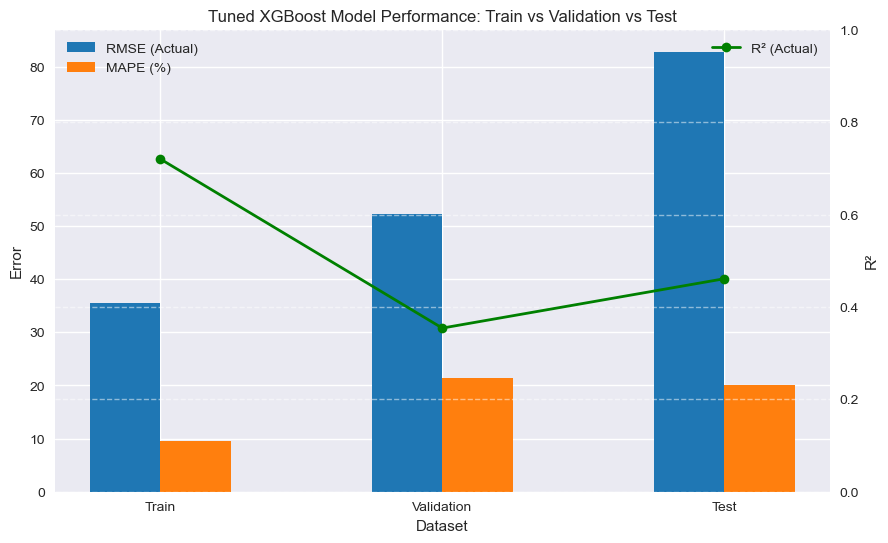

In [61]:
# Metrics to plot
datasets = ['Train', 'Validation', 'Test']
rmse_actual = [train_rmse_actual, val_rmse_actual, test_rmse_actual]
r2_actual = [train_r2_actual, val_r2_actual, test_r2_actual]
mape = [train_mape, val_mape, test_mape]

x = np.arange(len(datasets))  # the label locations
width = 0.25  # width of the bars

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot RMSE and MAPE as bars
ax1.bar(x - width/2, rmse_actual, width, label='RMSE (Actual)', color='#1f77b4')
ax1.bar(x + width/2, mape, width, label='MAPE (%)', color='#ff7f0e')
ax1.set_xlabel('Dataset')
ax1.set_ylabel('Error')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_title('Tuned XGBoost Model Performance: Train vs Validation vs Test')
ax1.legend(loc='upper left')

# Plot R² on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(datasets, r2_actual, color='green', marker='o', linewidth=2, label='R² (Actual)')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show();

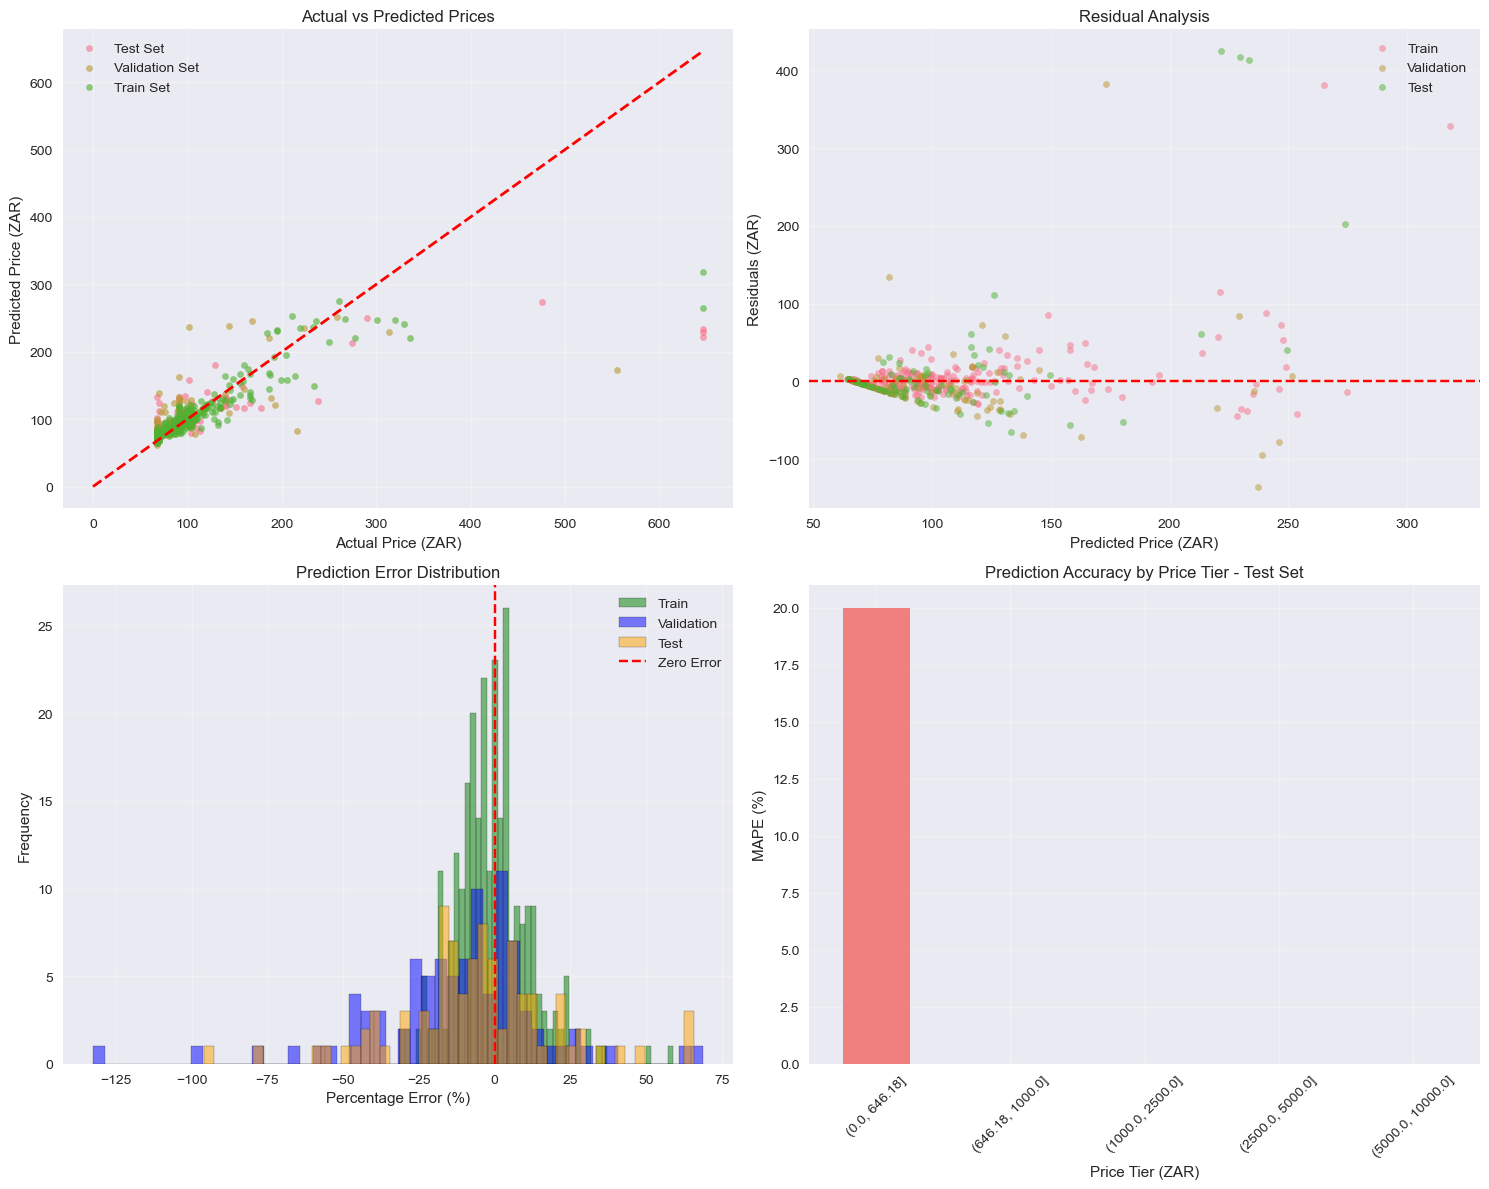

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted Prices - Test Set
axes[0,0].scatter(y_test_actual, y_test_pred, alpha=0.6, s=20, label='Test Set')
axes[0,0].scatter(y_val_actual, y_val_pred, alpha=0.6, s=20, label='Validation Set')
axes[0,0].scatter(y_train_actual, y_train_pred, alpha=0.6, s=20, label='Train Set')
axes[0,0].plot([0, max(y_test_actual.max(), y_train_actual.max())],
               [0, max(y_test_actual.max(), y_train_actual.max())], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Price (ZAR)')
axes[0,0].set_ylabel('Predicted Price (ZAR)')
axes[0,0].set_title('Actual vs Predicted Prices')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Residual Analysis - Test Set
residuals_train = y_train_actual - y_train_pred
residuals_val = y_val_actual - y_val_pred
residuals_test = y_test_actual - y_test_pred

axes[0,1].scatter(y_train_pred, residuals_train, alpha=0.5, s=20, label='Train')
axes[0,1].scatter(y_val_pred, residuals_val, alpha=0.5, s=20, label='Validation')
axes[0,1].scatter(y_test_pred, residuals_test, alpha=0.5, s=20, label='Test')
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Price (ZAR)')
axes[0,1].set_ylabel('Residuals (ZAR)')
axes[0,1].set_title('Residual Analysis')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Error Distribution - Test Set
error_train = ((y_train_actual - y_train_pred) / y_train_actual) * 100
error_val = ((y_val_actual - y_val_pred) / y_val_actual) * 100
error_test = ((y_test_actual - y_test_pred) / y_test_actual) * 100

axes[1,0].hist(error_train, bins=50, alpha=0.5, label='Train', color='green', edgecolor='black')
axes[1,0].hist(error_val, bins=50, alpha=0.5, label='Validation', color='blue', edgecolor='black')
axes[1,0].hist(error_test, bins=50, alpha=0.5, label='Test', color='orange', edgecolor='black')
axes[1,0].axvline(x=0, color='r', linestyle='--', label='Zero Error')
axes[1,0].set_xlabel('Percentage Error (%)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Prediction Error Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Price Tier Performance - Test Set
bins = sorted([0, 1000, 2500, 5000, 10000, y_test_actual.max()])
price_tiers_test = pd.cut(y_test_actual, bins=bins)
tier_performance_test = pd.DataFrame({
    'actual': y_test_actual,
    'predicted': y_test_pred,
    'tier': price_tiers_test
})
tier_mape_test = tier_performance_test.groupby('tier').apply(
    lambda x: np.mean(np.abs((x['actual'] - x['predicted']) / x['actual'])) * 100
)
tier_mape_test.plot(kind='bar', ax=axes[1,1], color='lightcoral')
axes[1,1].set_xlabel('Price Tier (ZAR)')
axes[1,1].set_ylabel('MAPE (%)')
axes[1,1].set_title('Prediction Accuracy by Price Tier - Test Set')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
pip install streamlit joblib

  Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl (413 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.8 which is incompatible.


In [64]:
import joblib
joblib.dump(xgb_pipeline, 'cape_town_model.pkl')

NameError: name 'xgb_pipeline' is not defined

<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 6. Conclusion </h2>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">

### **Model Performance:**

The tuned XGBoost model achieved high accuracy on the training set (R2 = 0.93, RMSE = 1006), indicating it captures strong patterns in the data.

On validation and test sets, the performance decreased (R2 = 0.70-0.73, RMSE = 1941-2039), showing the model generalizes reasonably well but with some overfitting.

MAPE values (23%) suggest that on average, the model’s predicted prices deviate by around 23% from actual Airbnb listing prices. This level of error is acceptable for pricing guidance, though not perfect.

### **Interpretability and Insights:**

The XGBoost model can provide feature importance scores, helping identify key factors affecting Airbnb prices in Cape Town, such as location, property type, and number of amenities.

This aligns with the project objective of not only predicting prices but also providing actionable insights for hosts.

### **Business Objective Alignment:**

The model successfully provides data-driven pricing guidance, supporting hosts in setting competitive yet profitable Airbnb rates.

While predictions are not flawless, they are better than generic pricing strategies and can be fine-tuned further with updated data and additional features.
</div>

<h2 style="font-family:'Inter', sans-serif; color:#2f5597; font-weight:600;"> 7. Recommendations </h2>

<div style="background-color:#f7f9fc; padding:15px; border-left:5px solid #2f5597; border-radius:6px;">
    
### **Address Overfitting:**

- Consider further tuning XGBoost hyperparameters, such as increasing min_child_weight, reducing max_depth, or adding more regularization (lambda/alpha).

### **Feature Engineering:**

- Include more features that capture dynamic pricing factors, e.g., local events, holidays, competitor prices, and seasonal trends.
- Encode categorical features more effectively (e.g., location clusters, property types) to improve predictive power.

### **Continuous Model Improvement:**

- Retrain the model periodically as Airbnb listings and demand patterns change.
- Use feedback from host adoption to refine predictions, focusing on reducing the MAPE further below 20%.
</div>